In [7]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from collections import Counter

def calculate_average_score_and_plot(folder_path):
    records = []
    langgraph = False
    step = []

    for filename in tqdm(os.listdir(folder_path)):
        if not filename.endswith('.json'):
            continue

        with open(os.path.join(folder_path, filename), 'r', encoding='utf-8') as f:
            data = json.load(f)


        if 'metrics' in data and 'pairing' in data:
            metrics = data['metrics']
            pairing = data['pairing']
            gt_list = [s for s in pairing.get("ground_truth", []) if s.strip()]
            gen_list = [s for s in pairing.get("generated", []) if s.strip()]
            gt_aspect_count = len(gt_list)
            gen_aspect_count = len(gen_list)
            abs_diff = metrics.get('#AbsAspDiff', abs(gt_aspect_count - gen_aspect_count))

            if 'total_steps' in data:
                records.append({
                    "filename": filename,
                    "gt_aspect_count": gt_aspect_count,
                    "gen_aspect_count": gen_aspect_count,
                    "AbsAspDiff": abs_diff,
                    "BERTScore": metrics.get('BERTScore', 0),
                    "ROUGE-1": metrics.get('ROUGE-1', 0),
                    "ROUGE-2": metrics.get('ROUGE-2', 0),
                    "ROUGE-L": metrics.get('ROUGE-L', 0),
                    "total step": data['total_steps']
                })
            else:
                records.append({
                    "filename": filename,
                    "gt_aspect_count": gt_aspect_count,
                    "gen_aspect_count": gen_aspect_count,
                    "AbsAspDiff": abs_diff,
                    "BERTScore": metrics.get('BERTScore', 0),
                    "ROUGE-1": metrics.get('ROUGE-1', 0),
                    "ROUGE-2": metrics.get('ROUGE-2', 0),
                    "ROUGE-L": metrics.get('ROUGE-L', 0),
                })

        if 'total_steps' in data:
            langgraph = True
            step.append(data['total_steps'])

    df = pd.DataFrame(records)

    # Calculate averages
    avg_scores = df[["BERTScore", "ROUGE-1", "ROUGE-2", "ROUGE-L", "AbsAspDiff"]].mean()

    print(f"Average BERTScore: {avg_scores['BERTScore']:.4f}")
    print(f"Average ROUGE-1: {avg_scores['ROUGE-1']:.4f}")
    print(f"Average ROUGE-2: {avg_scores['ROUGE-2']:.4f}")
    print(f"Average ROUGE-L: {avg_scores['ROUGE-L']:.4f}")
    print(f"Average #AbsAspDiff: {avg_scores['AbsAspDiff']:.4f}")

    if langgraph:
        print(f"Total Steps: {sum(step) / len(step):.4f}")


    # Scatter plot: GT aspect count vs ROUGE-1
    # plt.scatter(df["gt_aspect_count"], df["AbsAspDiff"])
    # plt.xlabel("Ground Truth Aspect Count")
    # plt.ylabel("AbsAspDiff")
    # plt.title("GT Aspect Count vs ROUGE-1 Score")
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()

    points = list(zip(df["gt_aspect_count"], df["AbsAspDiff"]))

    # Use Counter to get the frequency of each unique point
    point_counts = Counter(points)

    # Create lists for plotting, where each unique point is represented once
    # and its size is determined by its frequency
    plot_x = []
    plot_y = []
    plot_sizes = []

    for (x, y), count in point_counts.items():
        plot_x.append(x)
        plot_y.append(y)
        # Adjust the multiplier for point size as needed.
        # A larger multiplier will make the difference in size more pronounced.
        plot_sizes.append(count * 50)  # You can adjust '50' to control the base size

    plt.scatter(plot_x, plot_y, s=plot_sizes, alpha=0.7) # alpha adds transparency for better visibility of overlaps
    plt.xlabel("Ground Truth Aspect Count")
    plt.ylabel("BERTScore")
    plt.title("GT Aspect Count vs AbsAspDiff (Point Size by Density)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    counts = df["gt_aspect_count"].value_counts()
    print(counts)

    return df




100%|██████████| 70/70 [00:00<00:00, 5631.45it/s]

Average BERTScore: 0.5899
Average ROUGE-1: 0.4174
Average ROUGE-2: 0.2533
Average ROUGE-L: 0.3279
Average #AbsAspDiff: 2.4143


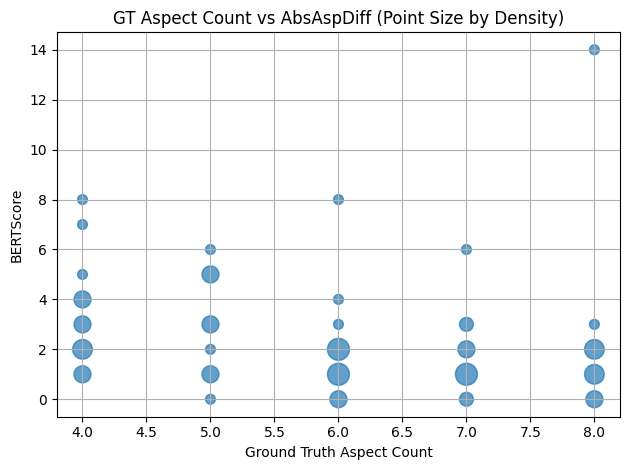

gt_aspect_count
4    16
6    16
8    13
7    13
5    12
Name: count, dtype: int64


,filename,gt_aspect_count,gen_aspect_count,AbsAspDiff,BERTScore,ROUGE-1,ROUGE-2,ROUGE-L
0,8_sample_3.json,8,8,0,0.752416,0.474068,0.245377,0.324112
1,8_sample_28.json,8,22,14,0.292911,0.207509,0.116371,0.168396
2,7_sample_55.json,7,10,3,0.503924,0.278883,0.154709,0.219571
3,4_sample_11.json,4,5,1,0.635612,0.449312,0.334727,0.378264
4,6_sample_36.json,6,6,0,0.815707,0.569647,0.335645,0.428751
...,...,...,...,...,...,...,...,...
65,4_sample_18.json,4,7,3,0.460990,0.340856,0.206076,0.293923
66,7_sample_67.json,7,8,1,0.698305,0.506781,0.274486,0.383673
67,7_sample_10.json,7,8,1,0.630901,0.383122,0.259290,0.302215
68,8_sample_42.json,8,9,1,0.686216,0.433598,0.225537,0.309306


In [12]:
calculate_average_score_and_plot("direct_prompt/gemini_filtered_data_y0n6/gemini-2.5-flash-lite")

100%|██████████| 70/70 [00:00<00:00, 6393.48it/s]

Average BERTScore: 0.6897
Average ROUGE-1: 0.5077
Average ROUGE-2: 0.3119
Average ROUGE-L: 0.4028
Average #AbsAspDiff: 1.2571


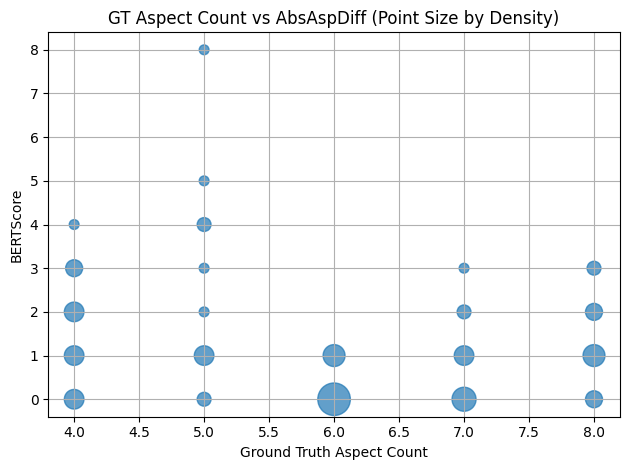

gt_aspect_count
4    16
6    16
8    13
7    13
5    12
Name: count, dtype: int64


,filename,gt_aspect_count,gen_aspect_count,AbsAspDiff,BERTScore,ROUGE-1,ROUGE-2,ROUGE-L
0,8_sample_3.json,8,6,2,0.630931,0.482726,0.314268,0.364635
1,8_sample_28.json,8,6,2,0.612400,0.430621,0.239423,0.330807
2,7_sample_55.json,7,7,0,0.785175,0.566520,0.358192,0.456978
3,4_sample_11.json,4,6,2,0.563565,0.418362,0.280973,0.384901
4,6_sample_36.json,6,6,0,0.789711,0.566025,0.299323,0.418192
...,...,...,...,...,...,...,...,...
65,4_sample_18.json,4,6,2,0.580005,0.490427,0.337669,0.441394
66,7_sample_67.json,7,10,3,0.599328,0.482594,0.297828,0.386188
67,7_sample_10.json,7,9,2,0.560796,0.350161,0.238826,0.276884
68,8_sample_42.json,8,8,0,0.790654,0.544733,0.282202,0.351845


In [13]:
calculate_average_score_and_plot("cot_sc_prompt/gemini_filtered_data_y6n0/gemini-2.5-flash-lite")

100%|██████████| 70/70 [00:00<00:00, 7134.73it/s]

Average BERTScore: 0.3080
Average ROUGE-1: 0.2242
Average ROUGE-2: 0.1362
Average ROUGE-L: 0.1788
Average #AbsAspDiff: 3.7857
Total Steps: 2.0857


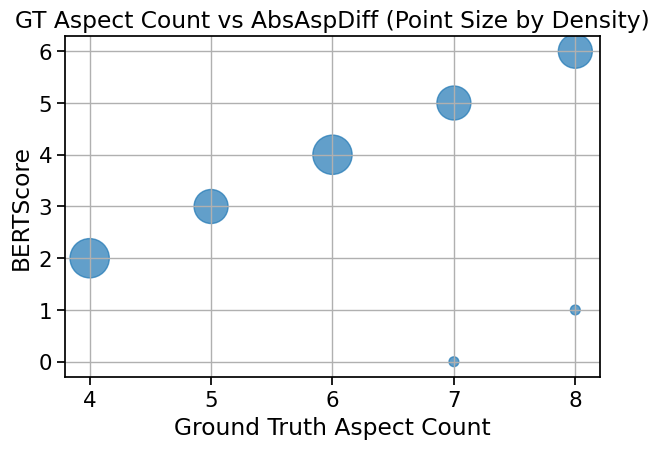

gt_aspect_count
4    16
6    16
8    13
7    13
5    12
Name: count, dtype: int64


,filename,gt_aspect_count,gen_aspect_count,AbsAspDiff,BERTScore,ROUGE-1,ROUGE-2,ROUGE-L,total step
0,8_sample_3.json,8,2,6,0.199416,0.144245,0.067502,0.088603,2
1,8_sample_28.json,8,2,6,0.208765,0.149842,0.073787,0.115532,2
2,7_sample_55.json,7,2,5,0.242196,0.181743,0.125356,0.154173,2
3,4_sample_11.json,4,2,2,0.447928,0.406813,0.315024,0.382491,2
4,6_sample_36.json,6,2,4,0.268764,0.206846,0.111207,0.157282,2
...,...,...,...,...,...,...,...,...,...
65,4_sample_18.json,4,2,2,0.455612,0.411397,0.337703,0.407299,2
66,7_sample_67.json,7,2,5,0.242982,0.181010,0.107849,0.150996,2
67,7_sample_10.json,7,7,0,0.725161,0.434286,0.286426,0.345723,6
68,8_sample_42.json,8,2,6,0.194512,0.130879,0.056624,0.087984,2


In [325]:
calculate_average_score_and_plot("langgraph_prompt_with_predicted_aspect/no_memory/gemini_filtered_data_y2n0/gpt-4o-mini-first")

100%|██████████| 70/70 [00:00<00:00, 5538.08it/s]

Average BERTScore: 0.5650
Average ROUGE-1: 0.3683
Average ROUGE-2: 0.2187
Average ROUGE-L: 0.2924
Average #AbsAspDiff: 2.2429
Total Steps: 4.0000


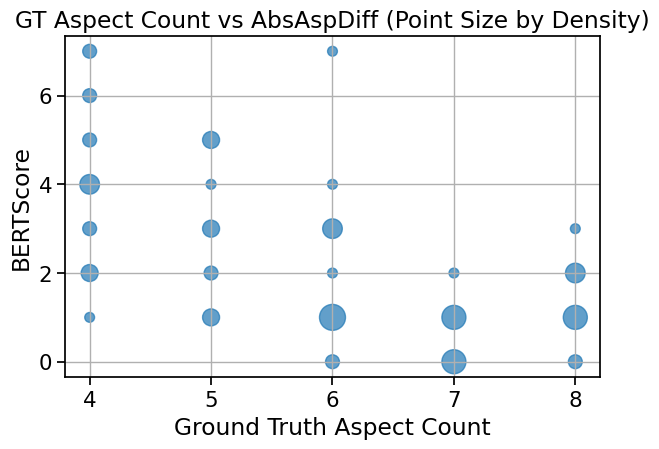

gt_aspect_count
4    16
6    16
8    13
7    13
5    12
Name: count, dtype: int64


,filename,gt_aspect_count,gen_aspect_count,AbsAspDiff,BERTScore,ROUGE-1,ROUGE-2,ROUGE-L,total step
0,8_sample_3.json,8,6,2,0.588194,0.381726,0.208269,0.286693,4
1,8_sample_28.json,8,8,0,0.718789,0.400185,0.184303,0.316157,4
2,7_sample_55.json,7,6,1,0.675434,0.459850,0.311581,0.390185,4
3,4_sample_11.json,4,10,6,0.311400,0.210543,0.147346,0.195301,4
4,6_sample_36.json,6,7,1,0.648907,0.397320,0.243138,0.307448,4
...,...,...,...,...,...,...,...,...,...
65,4_sample_18.json,4,8,4,0.414168,0.316642,0.218136,0.280611,4
66,7_sample_67.json,7,7,0,0.745301,0.469800,0.248277,0.369508,4
67,7_sample_10.json,7,8,1,0.638358,0.396503,0.264868,0.340911,4
68,8_sample_42.json,8,7,1,0.627599,0.353323,0.137762,0.234081,4


In [161]:
calculate_average_score_and_plot("langgraph/no_memory/gemini_filtered_data_y0n2/gemma-3-12b-it")

In [1]:
import os
import json
import pandas as pd
from tqdm import tqdm

# 所有基本參數
# METHODS = ["direct_prompt", "cot_prompt", "cot_sc_prompt"]
METHODS = ["direct_prompt_with_csv_aspect", "cot_prompt_with_csv_aspect", "cot_sc_prompt_with_csv_aspect"]
# SPECIAL_METHOD = "langgraph/no_memory"
SPECIAL_METHOD = "langgraph__prompt_with_csv_aspect"

SETTINGS = ["y2n2", "y4n4", "y6n6", "y2n0", "y4n0", "y6n0", "y0n2", "y0n4", "y0n6"]
MODELS = ["gpt-4o-mini", "gpt-4o", "gemma-3-12b-it", "gemma-3-27b-it", "gemini-2.5-flash-lite", "o3-mini-2025-01-31"]

BASE_PATH = "../Result/Chat_eval"


In [2]:
def process_folder(folder_path, method, setting, model):
    rows = []
    gt_count_list = []
    gen_count_list = []
    try:
        files = os.listdir(folder_path)
        # print(len(files), "files in", folder_path)
    except FileNotFoundError:
        return []

    for file in files:
        if not file.endswith(".json"):
            continue
        with open(os.path.join(folder_path, file), "r", encoding="utf-8") as f:
            data = json.load(f)

        if 'metrics' not in data or 'pairing' not in data:
            continue

        metrics = data["metrics"]
        pairing = data["pairing"]
        gt_list = [s for s in pairing.get("ground_truth", []) if s.strip()]
        gen_list = [s for s in pairing.get("generated", []) if s.strip()]
        gt_count = len(gt_list)
        gen_count = len(gen_list)
        abs_diff = metrics.get('#AbsAspDiff', abs(gt_count - gen_count))
        provided_aspect_count = len(data.get("provided_aspects", []))

        row = {
            "Method": method,
            "Model": model,
            "BERTScore": metrics.get("BERTScore", 0),
            "ROUGE-1": metrics.get("ROUGE-1", 0),
            "ROUGE-2": metrics.get("ROUGE-2", 0),
            "ROUGE-L": metrics.get("ROUGE-L", 0),
            "Factuality_score": metrics.get("factuality_score", 0),
            "Relevance_score": metrics.get("relevance_score", 0),
            "Aspect_bertscore_strict_avg": metrics.get("paired_aspect_bertscore_strict_avg", 0),
            "Aspect_bertscore_penalized_avg": metrics.get("paired_aspect_bertscore_penalized_avg", 0),
            "#AbsAspDiff": abs_diff,
            "#AvgStep": data.get("total_steps", None),
            "Total Tokens": data.get("total_tokens", 0),
            "Gen_Count": gen_count
        }
        rows.append(row)

        gt_count_list.append(gt_count)
        gen_count_list.append(gen_count)

    return rows, gt_count_list, gen_count_list



In [3]:
from scipy.stats import pearsonr

def summarize_by_setting():
    output_csv_dir = "./Chat_eval/summary_by_setting_all_variants_3"
    os.makedirs(output_csv_dir, exist_ok=True)

    for setting in SETTINGS:
        all_rows = []
        all_gt_counts = []
        all_gen_counts = []

        for variant_name, method_list in {
            "original": ["direct_prompt", "cot_prompt", "cot_sc_prompt"],
            "csv": ["direct_prompt_with_csv_aspect", "cot_prompt_with_csv_aspect", "cot_sc_prompt_with_csv_aspect"],
            "pred": ["direct_prompt_with_predicted_aspect", "cot_prompt_with_predicted_aspect", "cot_sc_prompt_with_predicted_aspect"]
        }.items():
            for method in method_list:
                for model in MODELS:
                    folder = os.path.join(BASE_PATH, method, f"gemini_filtered_data_{setting}", model)
                    rows, gt_count_list, gen_count_list = process_folder(folder, method, setting, model)
                    for r in rows:
                        r["AspectType"] = variant_name
                        r["Setting"] = setting
                        r["PromptMethod"] = method.replace("_with_csv_aspect", "").replace("_with_predicted_aspect", "")
                    all_rows.extend(rows)
                    all_gt_counts.extend(gt_count_list)

                    # if variant_name == "original" and model == "gpt-4o-mini" and method == "cot_prompt":
                    #     all_gen_counts.extend(gen_count_list)

        # 處理 langgraph separately
        for variant_name, lg_method_dir in {
            "original": "langgraph/no_memory",
            "csv": "langgraph_prompt_with_csv_aspect/no_memory",
            "pred": "langgraph_prompt_with_predicted_aspect/no_memory"
        }.items():
            for model in MODELS:
                folder = os.path.join(BASE_PATH, lg_method_dir, f"gemini_filtered_data_{setting}", model)
                rows, gt_count_list, gen_count_list = process_folder(folder, "agentic_workflow", setting, model)
                for r in rows:
                    r["AspectType"] = variant_name
                    r["Setting"] = setting
                    r["PromptMethod"] = "agentic_workflow"
                all_rows.extend(rows)
                all_gt_counts.extend(gt_count_list)
                # if variant_name == "original" and model == "gemma-3-12b-it"  and method == "direct_prompt":
                #     all_gen_counts.extend(gen_count_list)

        # 整理成 DataFrame
        df = pd.DataFrame(all_rows)
        df_grouped = df.groupby(["PromptMethod", "AspectType", "Model"]).mean(numeric_only=True).reset_index()
        df_grouped = df_grouped.round(4)

        df_grouped.to_csv(os.path.join(output_csv_dir, f"summary_{setting}.csv"), index=False)
        print(f"✅ Saved: summary_{setting}.csv")

        # print(len(all_gen_counts))  # Print first 10 counts for debugging
        # print(sum(all_gen_counts) / len(all_gen_counts))
        # df_2 = pd.DataFrame({
        #     "provided_aspect_count": all_gt_counts,
        #     "output_aspect_count": all_gen_counts
        # })

        # correlation, p_value = pearsonr(df_2["provided_aspect_count"], df_2["output_aspect_count"])

        # # 顯示結果
        # print(f"Pearson correlation: {correlation:.4f} (p-value = {p_value:.4f})")
        # print('======')
        
summarize_by_setting()

✅ Saved: summary_y2n2.csv
✅ Saved: summary_y4n4.csv
✅ Saved: summary_y6n6.csv
✅ Saved: summary_y2n0.csv
✅ Saved: summary_y4n0.csv
✅ Saved: summary_y6n0.csv
✅ Saved: summary_y0n2.csv
✅ Saved: summary_y0n4.csv
✅ Saved: summary_y0n6.csv


In [4]:
import pandas as pd
import os
import glob

SUMMARY_DIR = "./Chat_eval/summary_by_setting_all_variants_3"
OUTPUT_FILE = "./Chat_eval/summary_all3.csv"

def merge_all_summaries():
    all_files = glob.glob(os.path.join(SUMMARY_DIR, "summary_*.csv"))
    all_dfs = []

    for file in all_files:
        df = pd.read_csv(file)
        
        # 從檔名取出 setting，例如 summary_y2n2.csv → y2n2
        setting = os.path.basename(file).replace("summary_", "").replace(".csv", "")
        df["Setting"] = setting  # 加入設定欄位
        all_dfs.append(df)

    df_all = pd.concat(all_dfs, ignore_index=True)
    df_all.to_csv(OUTPUT_FILE, index=False)
    print(f"✅ Merged {len(all_files)} files into: {OUTPUT_FILE}")

merge_all_summaries()


✅ Merged 9 files into: ./Chat_eval/summary_all3.csv


In [5]:
# Rename

import pandas as pd

# 檔案名稱
input_filename = './Chat_eval/summary_all3.csv'
output_filename = './Chat_eval/summary_all3_rename.csv'

try:
    # 1. 直接從 CSV 檔案讀取資料
    df = pd.read_csv(input_filename)
    print(f"成功讀取檔案: {input_filename}")

    # 2. 針對特定欄位進行替換
    #    您可以在這裡修改 'new_workflow_name' 和 'prediction_type' 成您想要的名字
    df['PromptMethod'] = df['PromptMethod'].replace({'agentic_workflow': 'self-refine'})
    df['AspectType'] = df['AspectType'].replace({'pred': 'LLMs'})
    df['AspectType'] = df['AspectType'].replace({'csv': 'regression_model'})
    df['AspectType'] = df['AspectType'].replace({'original': 'preliminary'})

    # 3. 將修改後的資料儲存成新的 CSV 檔案
    df.to_csv(output_filename, index=False)
    print(f"修改後的資料已成功儲存至: {output_filename}")

    # 4. 印出修改後結果的最後幾行以供確認
    print("\n修改後資料預覽 (末五行)：")
    print(df.tail())

except FileNotFoundError:
    print(f"錯誤：找不到檔案 '{input_filename}'。")
    print("請確認檔案名稱是否正確，並且與您的 Python 程式碼放在同一個資料夾中。")
except Exception as e:
    print(f"發生預期外的錯誤: {e}")

成功讀取檔案: ./Chat_eval/summary_all3.csv
修改後的資料已成功儲存至: ./Chat_eval/summary_all3_rename.csv

修改後資料預覽 (末五行)：
      PromptMethod AspectType               Model  BERTScore  ROUGE-1  \
643  direct_prompt       LLMs      gemma-3-12b-it     0.5397   0.3782   
644  direct_prompt       LLMs      gemma-3-27b-it     0.6187   0.4100   
645  direct_prompt       LLMs              gpt-4o     0.5645   0.3638   
646  direct_prompt       LLMs         gpt-4o-mini     0.5079   0.3039   
647  direct_prompt       LLMs  o3-mini-2025-01-31     0.5959   0.3465   

     ROUGE-2  ROUGE-L  Factuality_score  Relevance_score  \
643   0.2454   0.3052            4.6857           3.7571   
644   0.2368   0.3203            4.6286           3.8571   
645   0.1988   0.2795            4.7000           3.7143   
646   0.1527   0.2294            4.6000           3.0000   
647   0.1491   0.2464            4.8000           3.9571   

     Aspect_bertscore_strict_avg  Aspect_bertscore_penalized_avg  #AbsAspDiff  \
643             

In [374]:
import pandas as pd

# 讀取資料
df = pd.read_csv("summary_all2.csv")

# 選取 BERTScore 與相關欄位
df_sub = df[["PromptMethod", "AspectType", "Model", "Setting", "BERTScore"]]

# 將 csv 與 original 分開，再合併比對每個組合
df_csv = df_sub[df_sub["AspectType"] == "csv"].copy()
df_ori = df_sub[df_sub["AspectType"] == "original"].copy()

# 合併條件：PromptMethod, Model, Setting
merged = pd.merge(
    df_csv,
    df_ori,
    on=["PromptMethod", "Model", "Setting"],
    suffixes=("_csv", "_original")
)

# 計算百分比提升
merged["BERTScore_Improvement_%"] = (
    (merged["BERTScore_csv"] - merged["BERTScore_original"]) / merged["BERTScore_original"]
) * 100

# 計算平均提升
mean_improvement = merged["BERTScore_Improvement_%"].mean()

print(f"📈 平均 BERTScore 提升百分比（csv vs. original）：{mean_improvement:.2f}%")


📈 平均 BERTScore 提升百分比（csv vs. original）：25.41%


In [15]:
import pandas as pd

# 讀取資料
df = pd.read_csv("summary_all.csv")

# 選取 BERTScore 與相關欄位
df_sub = df[["PromptMethod", "AspectType", "Model", "Setting", "ROUGE-L"]]

# 將 csv 與 original 分開，再合併比對每個組合
df_csv = df_sub[df_sub["AspectType"] == "csv"].copy()
df_ori = df_sub[df_sub["AspectType"] == "original"].copy()

# 合併條件：PromptMethod, Model, Setting
merged = pd.merge(
    df_csv,
    df_ori,
    on=["PromptMethod", "Model", "Setting"],
    suffixes=("_csv", "_original")
)

# 計算百分比提升
merged["ROUGE-L_Improvement_%"] = (
    (merged["ROUGE-L_csv"] - merged["ROUGE-L_original"]) / merged["ROUGE-L_original"]
) * 100

# 計算平均提升
mean_improvement = merged["ROUGE-L_Improvement_%"].mean()

print(f"📈 平均 ROUGE-L 提升百分比（csv vs. original）：{mean_improvement:.2f}%")

📈 平均 ROUGE-L 提升百分比（csv vs. original）：19.82%


In [14]:
import pandas as pd

# 讀取資料
df = pd.read_csv("summary_all.csv")

# 選取 #AbsAspDiff 與相關欄位
df_sub = df[["PromptMethod", "AspectType", "Model", "Setting", "#AbsAspDiff"]]

# 將 csv 與 original 分開，再合併比對每個組合
df_csv = df_sub[df_sub["AspectType"] == "csv"].copy()
df_ori = df_sub[df_sub["AspectType"] == "original"].copy()

# 合併條件：PromptMethod, Model, Setting
merged = pd.merge(
    df_csv,
    df_ori,
    on=["PromptMethod", "Model", "Setting"],
    suffixes=("_csv", "_original")
)

# 計算百分比提升
merged["#AbsAspDiff_Improvement_%"] = (
    (merged["#AbsAspDiff_csv"] - merged["#AbsAspDiff_original"]) / merged["#AbsAspDiff_original"]
) * 100

# 計算平均提升
mean_improvement = merged["#AbsAspDiff_Improvement_%"].mean()

print(f"📈 平均 #AbsAspDiff 提升百分比（csv vs. original）：{mean_improvement:.2f}%")

📈 平均 #AbsAspDiff 提升百分比（csv vs. original）：-71.74%


In [3]:
import pandas as pd

# 載入 CSV 檔案到 pandas DataFrame
df = pd.read_csv('Chat_eval/summary_all3_rename.csv')

# 篩選 'PromptMethod' 為 'self-refine' 的資料
self_refine_df = df[df['PromptMethod'] == 'self-refine']
# self_refine_df = df

# 根據 'AspectType' 和 'Model' 分組並計算平均值，這樣就會將 'Setting' 的影響平均掉
averaged_df = self_refine_df.groupby(["AspectType", 'Model']).mean(numeric_only=True)
print(averaged_df.head())

# 選取並顯示所需的欄位
result_df = averaged_df[['#AvgStep', 'BERTScore', '#AbsAspDiff']]
# result_df = averaged_df[['Factuality_score', 'Relevance_score', 'Aspect_bertscore_strict_avg', 'Aspect_bertscore_penalized_avg']]


result_df.to_csv('Chat_eval/averaged_self_refine_summary.csv', index=True)
# result_df.to_csv('Chat_eval/averaged_summary.csv', index=True)
# result_df.to_csv('Chat_eval/averaged_step.csv', index=True)

                                  BERTScore   ROUGE-1   ROUGE-2   ROUGE-L  \
AspectType Model                                                            
LLMs       gemini-2.5-flash-lite   0.496211  0.357511  0.223678  0.287656   
           gemma-3-12b-it          0.561044  0.392356  0.252156  0.319522   
           gemma-3-27b-it          0.531678  0.362789  0.218789  0.289900   
           gpt-4o                  0.553300  0.373156  0.209000  0.287222   
           gpt-4o-mini             0.525833  0.338389  0.190233  0.264389   

                                  Factuality_score  Relevance_score  \
AspectType Model                                                      
LLMs       gemini-2.5-flash-lite          4.650800         3.923811   
           gemma-3-12b-it                 4.715867         3.899989   
           gemma-3-27b-it                 4.758733         3.471422   
           gpt-4o                         4.704778         3.703178   
           gpt-4o-mini            

/tmp/ipykernel_3096363/3301683111.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


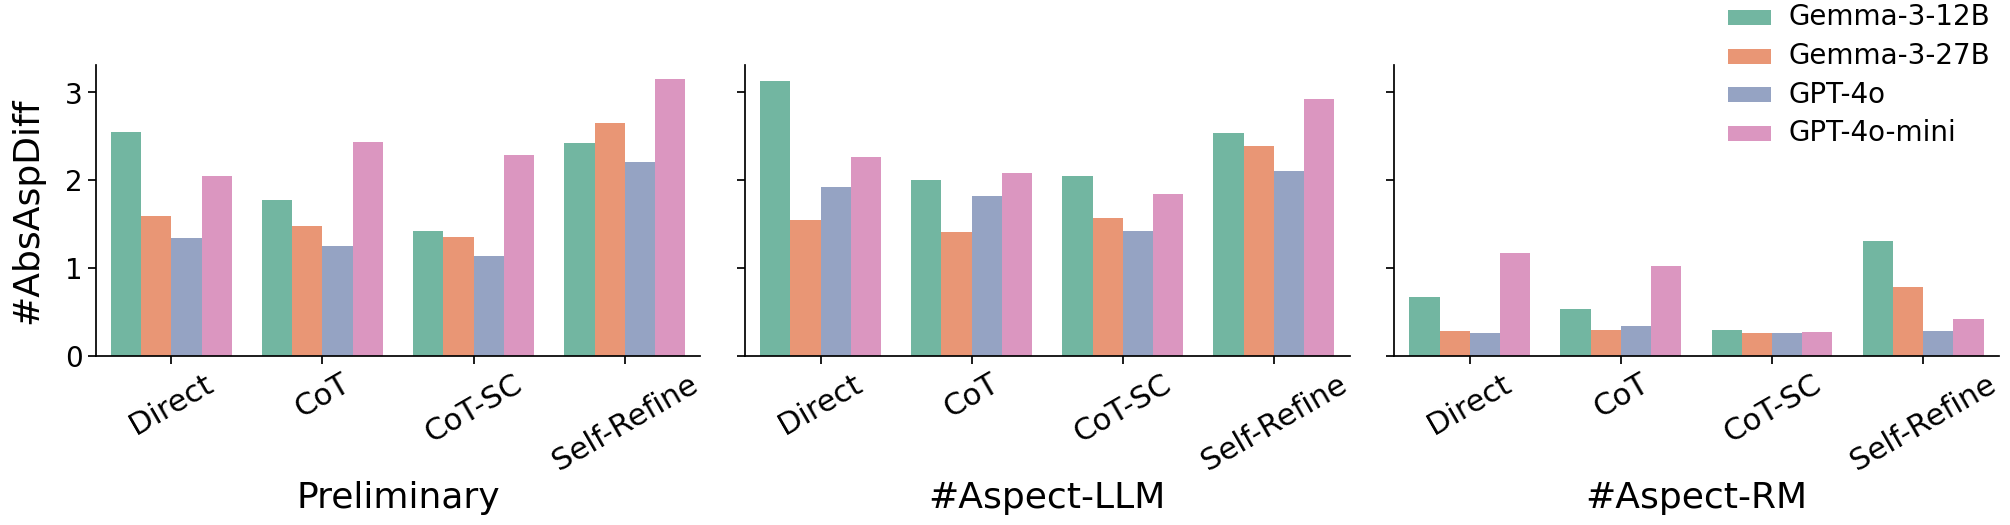

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./summary_all2.csv")

# 對 Method 做簡化命名
method_mapping = {
    "direct_prompt": "Direct",
    "direct_prompt_with_csv_aspect": "Direct",
    "direct_prompt_with_predicted_aspect": "Direct",
    "cot_prompt": "CoT",
    "cot_prompt_with_csv_aspect": "CoT",
    "cot_prompt_with_predicted_aspect": "CoT",
    "cot_sc_prompt": "CoT-SC",
    "cot_sc_prompt_with_csv_aspect": "CoT-SC",
    "cot_sc_prompt_with_predicted_aspect": "CoT-SC",
    "agentic_workflow": "Self-Refine",
}
df["Method"] = df["PromptMethod"].replace(method_mapping)

# 定義 col 順序與名稱對應
aspect_order = ["original", "pred", "csv"]
aspect_title_map = {
    "original": "Preliminary",
    "pred": "#Aspect-LLM",
    "csv": "#Aspect-RM",
}

# 設定整體字體大小
sns.set_context("notebook", font_scale=1.4)  # 或用 "talk", "poster" 等

# 畫圖
g = sns.catplot(
    data=df,
    kind="bar",
    x="Method",
    y="#AbsAspDiff",
    hue="Model",
    col="AspectType",
    col_order=aspect_order,
    order=["Direct", "CoT", "CoT-SC", "Self-Refine"],
    palette="Set2",
    ci=None,
    height=5,
    aspect=1.2
)

# 替換 facet 標題 & 設定字體大小
for ax, title in zip(g.axes.flat, aspect_order):
    # ax.set_title(aspect_title_map[title], fontsize=18)
    # ax.set_xlabel("Method", fontsize=18)
    ax.set_title("")
    ax.set_xlabel(aspect_title_map[title], fontsize=26)
    ax.set_ylabel("#AbsAspDiff", fontsize=26, labelpad=15)
    ax.tick_params(axis='x', labelsize=22)
    ax.tick_params(axis='y', labelsize=20)

replace_dict = {
    "gemma-3-12b-it": "Gemma-3-12B",
    "gemma-3-27b-it": "Gemma-3-27B",
    "gpt-4o": "GPT-4o",
    "gpt-4o-mini": "GPT-4o-mini"
}


# 調整 xtick 角度與圖例
g.set_xticklabels(rotation=30)
g._legend.set_title("", prop={"size": 20})
for text in g.legend.texts:
    # 取得當前的文字標籤 (例如 "gemma-3-12b-it")
    current_label = text.get_text()
    
    # 從 replace_dict 字典中找到對應的新名稱，如果找不到就用回原名
    new_label = replace_dict.get(current_label, current_label)
    
    # 設定新的文字標籤
    text.set_text(new_label)
    
    # 設定字體大小 (這行可以保留)
    text.set_fontsize(20)
g._legend.set_bbox_to_anchor((0.98, 0.9))

plt.tight_layout()
plt.show()
g.savefig("aspect_type_comparison_AbsAspDiff2.png", dpi=300, bbox_inches='tight')


數據加載成功！

--- 1. 按 'Parsed Setting' 和 'PromptMethod' 分組的平均表現 ---

--- 2. 按 'Parsed Setting', 'PromptMethod', 'Model' 分組的平均表現 ---


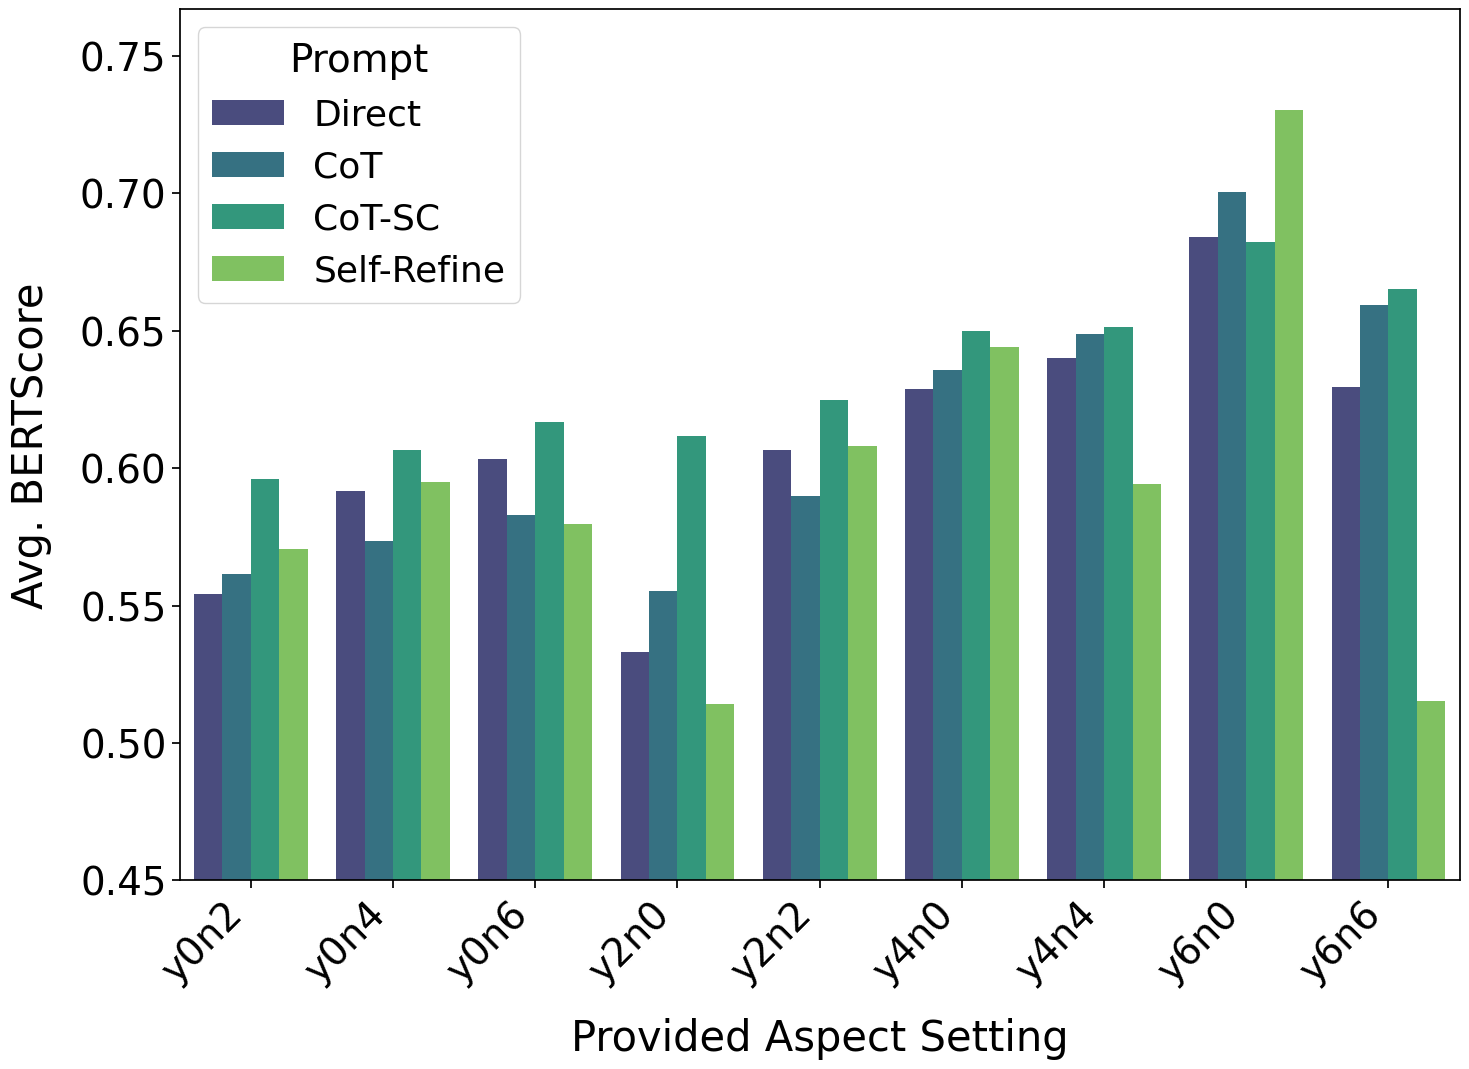

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    df = pd.read_csv('summary_all_rename.csv')
    print("數據加載成功！")
except FileNotFoundError:
    print("錯誤：'summary_all_rename.csv' 文件未找到。請確保文件在正確的路徑下。")
    exit()

# 數據清洗：確保數值列是數值類型
# 由於 #AbsAspDiff 和 #AvgStep 可能有缺失值或非數值，將其轉換為數值，非數值設為 NaN
df['#AbsAspDiff'] = pd.to_numeric(df['#AbsAspDiff'], errors='coerce')
df['#AvgStep'] = pd.to_numeric(df['#AvgStep'], errors='coerce')
df['Total Tokens'] = pd.to_numeric(df['Total Tokens'], errors='coerce')

# 為了更好地分析，我們將 'Setting' 列進行標準化處理
# 假設 'Setting' 列的格式是 'yXnZ' 或 'yX' 或 'nX'，我們提取數字部分
def parse_setting(setting):
    if pd.isna(setting):
        return None
    setting = str(setting).lower().strip()
    if 'y' in setting and 'n' in setting:
        parts = setting.split('n')
        y_count = int(parts[0].replace('y', '')) if parts[0].replace('y', '').isdigit() else 0
        n_count = int(parts[1]) if parts[1].isdigit() else 0
        return f"y{y_count}n{n_count}"
    elif 'y' in setting:
        y_count = int(setting.replace('y', '')) if setting.replace('y', '').isdigit() else 0
        return f"Correct (y{y_count})"
    elif 'n' in setting:
        n_count = int(setting.replace('n', '')) if setting.replace('n', '').isdigit() else 0
        return f"Incorrect (n{n_count})"
    return setting # 返回原始值如果無法解析

df['Parsed Setting'] = df['Setting'].apply(parse_setting)

# 移除 Setting 為 NaN 的行，因為這些行可能無法有效分析
df.dropna(subset=['Parsed Setting'], inplace=True)

# 定義我們感興趣的評估指標
metrics = ['BERTScore', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', '#AbsAspDiff', 'Total Tokens']

# 1. 按 'Parsed Setting' 和 'PromptMethod' 分組，計算平均值
print("\n--- 1. 按 'Parsed Setting' 和 'PromptMethod' 分組的平均表現 ---")
avg_performance_by_setting_prompt = df.groupby(['Parsed Setting', 'PromptMethod'])[metrics].mean().reset_index()
avg_performance_by_setting_prompt.to_csv('avg_performance_by_setting_prompt.csv', index=False)
# print(avg_performance_by_setting_prompt)

# 2. 按 'Parsed Setting'、'PromptMethod' 和 'Model' 分組，計算平均值 (更細粒度)
print("\n--- 2. 按 'Parsed Setting', 'PromptMethod', 'Model' 分組的平均表現 ---")
avg_performance_detailed = df.groupby(['Parsed Setting', 'PromptMethod', 'Model'])[metrics].mean().reset_index()
avg_performance_detailed.to_csv('avg_performance_detailed.csv', index=False)
# print(avg_performance_detailed)

# 3. 針對 'Preliminary' 和 'Regression Model' 預測的特定對比
# 篩選出 Preliminary 和 Regression Model 的數據
# prelim_reg_data = df[df['PromptMethod'].isin(['preliminary', 'regression_model'])].copy()
# if not prelim_reg_data.empty:
#     print("\n--- 3. 'preliminary' vs 'regression_model' 對比 ---")
#     avg_prelim_reg = prelim_reg_data.groupby(['Parsed Setting', 'PromptMethod'])[metrics].mean().reset_index()
#     avg_prelim_reg.to_csv('avg_prelim_reg.csv', index=False)
#     # print(avg_prelim_reg)
# else:
#     print("\n--- 3. 'preliminary' 或 'regression_model' 數據未找到，跳過對比 ---")


# --- 數據可視化建議 ---
# 這些是生成圖表的代碼範例，您可以根據需要取消註釋並運行

# 範例 1: 比較不同 'Parsed Setting' 下的 BERTScore (按 PromptMethod)
plt.figure(figsize=(15, 11))

# 複製 DataFrame 並修改列名和值以用於繪圖
plot_df = avg_performance_by_setting_prompt.copy()
plot_df.rename(columns={'PromptMethod': 'Prompt'}, inplace=True) # 將 'PromptMethod' 改為 'Prompt'

desired_prompt_order = {
    'direct_prompt': 'Direct',
    'cot_prompt': 'CoT',
    'cot_sc_prompt': 'CoT-SC',
    'self-refine': 'Self-Refine',
}


plot_df['Prompt'] = plot_df['Prompt'].replace(desired_prompt_order)

plot_df['Prompt'] = pd.Categorical(plot_df['Prompt'], categories=list(desired_prompt_order.values()), ordered=True)

sns.barplot(data=plot_df, x='Parsed Setting', y='BERTScore', hue='Prompt', palette='viridis') # 使用新的 'Prompt' 列
plt.title('') # 標題留空，通常在論文中會用 \caption
plt.xlabel('Provided Aspect Setting', fontsize=30, labelpad=20)
plt.ylabel('Avg. BERTScore', fontsize=30, labelpad=20)
plt.xticks(rotation=45, ha='right', fontsize=28)
plt.yticks(fontsize=28)
plt.legend(title='Prompt', title_fontsize='28', fontsize='26')
plt.ylim(0.45, plot_df['BERTScore'].max() * 1.05)
plt.tight_layout()
plt.savefig('bert_score_by_setting_prompt.png', dpi=300, bbox_inches='tight')
# plt.show()
# # 範例 2: 比較不同 'Parsed Setting' 下的 #AbsAspDiff (按 PromptMethod)
# plt.figure(figsize=(14, 7))
# sns.barplot(data=avg_performance_by_setting_prompt, x='Parsed Setting', y='#AbsAspDiff', hue='PromptMethod', palette='magma')
# plt.title('不同初始方面設定下各提示方法的平均 #AbsAspDiff')
# plt.xlabel('初始方面設定')
# plt.ylabel('平均 #AbsAspDiff (越低越好)')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

# # 範例 3: 比較 'Preliminary' 和 'Regression Model' 在特定 Setting 下的表現
# # 選擇一個 Setting 進行詳細對比，例如 'Mix (y2n2)'
# selected_setting_data = prelim_reg_data[prelim_reg_data['Parsed Setting'] == 'Mix (y2n2)']
# if not selected_setting_data.empty:
#     plt.figure(figsize=(12, 6))
#     sns.barplot(data=selected_setting_data, x='PromptMethod', y='BERTScore', hue='Model', palette='coolwarm')
#     plt.title('Mix (y2n2) 設定下 Preliminary vs Regression Model 的 BERTScore')
#     plt.xlabel('方法')
#     plt.ylabel('平均 BERTScore')
#     plt.tight_layout()
#     plt.show()

# print("\n數據分析腳本已執行。請查看控制台輸出以獲取聚合數據。")
# print("您可以取消註釋代碼末尾的可視化部分，以生成圖表進行更直觀的分析。")
# print("\n--- 3. 每個 'Parsed Setting' 的 BERTScore 總平均 ---")
# avg_bertscore_per_setting = avg_performance_by_setting_prompt.groupby('Parsed Setting')['BERTScore'].mean().reset_index()
# avg_bertscore_per_setting.rename(columns={'BERTScore': 'Overall Avg. BERTScore'}, inplace=True)
# print(avg_bertscore_per_setting)

# # 繪製每個 Setting 的 BERTScore 總平均圖
# plt.figure(figsize=(12, 8))
# sns.barplot(data=avg_bertscore_per_setting, x='Parsed Setting', y='Overall Avg. BERTScore', palette='cubehelix')
# plt.title('不同初始方面設定下 BERTScore 的總平均表現', fontsize=20)
# plt.xlabel('初始方面設定', fontsize=16)
# plt.ylabel('BERTScore 總平均', fontsize=16)
# plt.xticks(rotation=45, ha='right', fontsize=14)
# plt.yticks(fontsize=14)
# plt.ylim(0.45, avg_bertscore_per_setting['Overall Avg. BERTScore'].max() * 1.05) # 調整 Y 軸範圍
# plt.tight_layout()
# plt.savefig('overall_avg_bert_score_by_setting.png', dpi=300, bbox_inches='tight')
# plt.show()


數據加載成功！


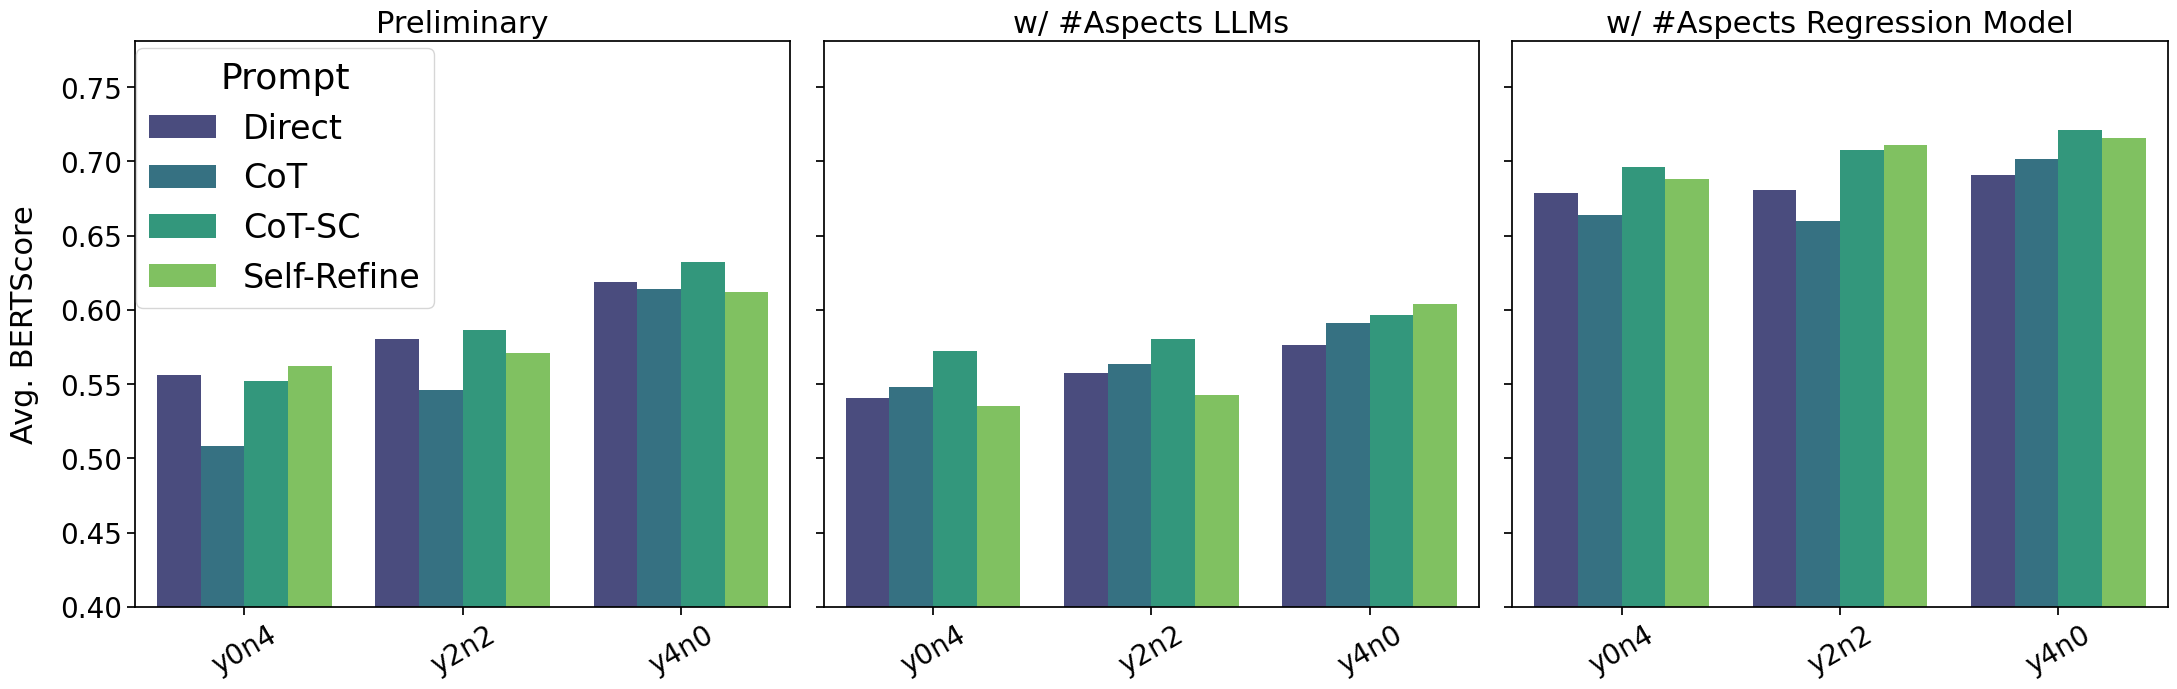


合併後的圖表 'bert_score_comparison_combined.png' 已生成並保存。


In [255]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    # 確保您已經上傳 'summary_all_rename.csv' 檔案
    df = pd.read_csv('summary_all_rename.csv')
    print("數據加載成功！")
except FileNotFoundError:
    print("錯誤：'summary_all_rename.csv' 文件未找到。請確保文件在正確的路徑下或已上傳。")
    exit()

# 數據清洗：確保數值列是數值類型
df['#AbsAspDiff'] = pd.to_numeric(df['#AbsAspDiff'], errors='coerce')
df['#AvgStep'] = pd.to_numeric(df['#AvgStep'], errors='coerce')
df['Total Tokens'] = pd.to_numeric(df['Total Tokens'], errors='coerce')

# 為了更好地分析，我們將 'Setting' 列進行標準化處理
def parse_setting(setting):
    if pd.isna(setting):
        return None
    setting = str(setting).lower().strip()
    if 'y' in setting and 'n' in setting:
        parts = setting.split('n')
        y_count = int(parts[0].replace('y', '')) if parts[0].replace('y', '').isdigit() else 0
        n_count = int(parts[1]) if parts[1].isdigit() else 0
        return f"y{y_count}n{n_count}"
    elif 'y' in setting:
        y_count = int(setting.replace('y', '')) if setting.replace('y', '').isdigit() else 0
        return f"y{y_count}n0"
    elif 'n' in setting:
        n_count = int(setting.replace('n', '')) if setting.replace('n', '').isdigit() else 0
        return f"y0n{n_count}"
    return setting

df['Parsed Setting'] = df['Setting'].apply(parse_setting)

# 移除 Setting 為 NaN 的行
df.dropna(subset=['Parsed Setting'], inplace=True)

# 將數據從寬格式轉換為長格式，只關注 BERTScore
df_long_melted = df.melt(
    id_vars=['Parsed Setting', 'Model', 'PromptMethod', 'AspectType'],
    value_vars=['BERTScore'],
    var_name='Metric',
    value_name='Score'
)

# 創建 AspectTypeDisplay 列 (替換名稱以利顯示)
df_long_melted['AspectTypeDisplay'] = df_long_melted['AspectType'].replace({
    'preliminary': 'Preliminary', # 將 'preliminary' 對應到 'Original Input'
    'regression_model': 'w/ #Aspects Regression Model',
    'LLMs': 'w/ #Aspects LLMs'
})

# 創建 Prompt 列 (替換名稱以利顯示)
prompt_name_mapping = {
    'direct_prompt': 'Direct',
    'cot_prompt': 'CoT',
    'cot_sc_prompt': 'CoT-SC',
    'self-refine': 'Self-Refine',
    'agentic_workflow': 'Agentic Workflow',
}
# 我們只處理沒有 'with' 的基礎 prompt method，因為AspectTypeDisplay已經區分了引導類型
df_long_melted['Prompt'] = df_long_melted['PromptMethod'].map(prompt_name_mapping)

# 移除那些在 mapping 中找不到對應的 PromptMethod (例如 'direct_prompt_with_csv_aspect')
df_long_melted.dropna(subset=['Prompt'], inplace=True)


# 定義 Prompt 的顯示順序
desired_prompt_order = ['Direct', 'CoT', 'CoT-SC', 'Self-Refine', 'Agentic Workflow']
df_long_melted['Prompt'] = pd.Categorical(
    df_long_melted['Prompt'],
    categories=[p for p in desired_prompt_order if p in df_long_melted['Prompt'].unique()],
    ordered=True
)

# --- 主要修改從這裡開始 ---

# 1. 篩選出需要繪製的 Setting 和 AspectTypeDisplay
target_settings = ['y0n4', 'y2n2', 'y4n0']
target_aspect_types = ['Preliminary', 'w/ #Aspects LLMs', 'w/ #Aspects Regression Model']

# 過濾掉不需要的數據，只保留目標 Setting 和 AspectType
df_plot_data = df_long_melted[
    df_long_melted['Parsed Setting'].isin(target_settings) &
    df_long_melted['AspectTypeDisplay'].isin(target_aspect_types)
].copy()

# 將 Parsed Setting 也轉換為類別類型，以確保 X 軸順序正確
df_plot_data['Parsed Setting'] = pd.Categorical(
    df_plot_data['Parsed Setting'],
    categories=target_settings,
    ordered=True
)

# 2. 創建一個包含 1 行 3 列的子圖畫布，並共享 Y 軸
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

# 3. 遍歷三種 Aspect Type，並在對應的子圖上繪圖
for i, aspect_type_to_plot in enumerate(target_aspect_types):
    ax = axes[i] # 選擇當前的子圖
    
    # 篩選出當前循環需要的數據
    df_subset = df_plot_data[df_plot_data['AspectTypeDisplay'] == aspect_type_to_plot]

    sns.barplot(
        data=df_subset,
        x='Parsed Setting',
        y='Score',
        hue='Prompt',
        palette='viridis',
        # errorbar='sd',
        errorbar=None,  # 關閉誤差條
        ax=ax # **指定在當前的子圖 (ax) 上繪製**
    )

    # 設定每個子圖的標題和 X 軸標籤
    ax.set_title(f'{aspect_type_to_plot}', fontsize=22)
    ax.set_xlabel('', fontsize=14)
    ax.tick_params(axis='x', rotation=30, labelsize=20)
    ax.set_ylim(0.4, df_plot_data['Score'].max() * 1.05)
    
    # 移除每個子圖自己的圖例，我們之後會創建一個共享的
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# 4. 設定共享的 Y 軸標籤 (只需要在最左邊的圖顯示)
axes[0].set_ylabel('Avg. BERTScore', fontsize=22, labelpad=15)
axes[0].tick_params(axis='y', labelsize=20)

# 5. 創建一個共享的圖例
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Prompt', title_fontsize='26', fontsize='24', 
           bbox_to_anchor=(0.063, 0.82), loc='upper left', borderaxespad=0.)

# 6. 為整張圖添加一個主標題
# fig.suptitle('BERTScore Comparison Across Different Aspect Types and Settings', fontsize=22, y=1.02)

# 7. 自動調整版面並保存圖表
# rect 參數 [left, bottom, right, top] 調整主繪圖區域，為右側的圖例留出空間
plt.tight_layout(rect=[0, 0, 0.92, 0.9]) 
plt.savefig('bert_score_comparison_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n合併後的圖表 'bert_score_comparison_combined.png' 已生成並保存。")

數據加載成功！


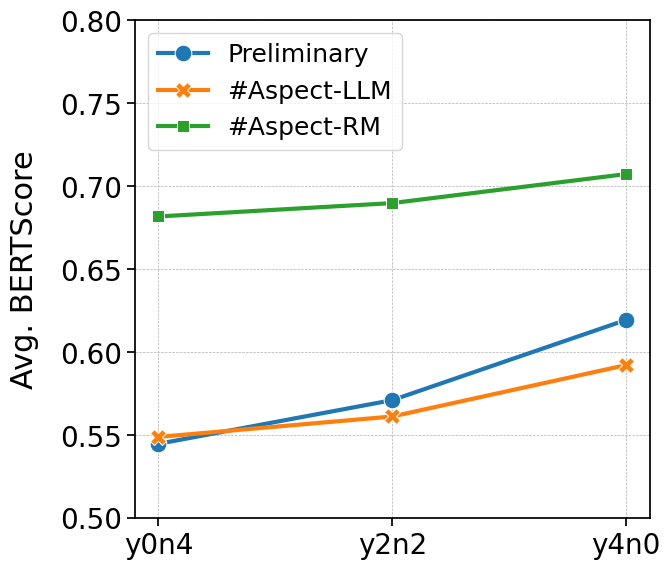


將三條折線合併後的圖表 'bert_score_lines_combined.png' 已生成並保存。


In [339]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    # 確保您已經上傳 'summary_all_rename.csv' 檔案
    df = pd.read_csv('summary_all_rename.csv')
    print("數據加載成功！")
except FileNotFoundError:
    print("錯誤：'summary_all_rename.csv' 文件未找到。請確保文件在正確的路徑下或已上傳。")
    exit()

# --- 數據準備 (與您提供的代碼相同) ---
df['#AbsAspDiff'] = pd.to_numeric(df['#AbsAspDiff'], errors='coerce')
df['#AvgStep'] = pd.to_numeric(df['#AvgStep'], errors='coerce')
df['Total Tokens'] = pd.to_numeric(df['Total Tokens'], errors='coerce')

def parse_setting(setting):
    if pd.isna(setting):
        return None
    setting = str(setting).lower().strip()
    if 'y' in setting and 'n' in setting:
        parts = setting.split('n')
        y_count = int(parts[0].replace('y', '')) if parts[0].replace('y', '').isdigit() else 0
        n_count = int(parts[1]) if parts[1].isdigit() else 0
        return f"y{y_count}n{n_count}"
    elif 'y' in setting:
        y_count = int(setting.replace('y', '')) if setting.replace('y', '').isdigit() else 0
        return f"y{y_count}n0"
    elif 'n' in setting:
        n_count = int(setting.replace('n', '')) if setting.replace('n', '').isdigit() else 0
        return f"y0n{n_count}"
    return setting

df['Parsed Setting'] = df['Setting'].apply(parse_setting)
df.dropna(subset=['Parsed Setting'], inplace=True)

df_long_melted = df.melt(
    id_vars=['Parsed Setting', 'Model', 'PromptMethod', 'AspectType'],
    value_vars=['BERTScore'],
    var_name='Metric',
    value_name='Score'
)

df_long_melted['AspectTypeDisplay'] = df_long_melted['AspectType'].replace({
    'preliminary': 'Preliminary',
    'regression_model': '#Aspect-RM',
    'LLMs': '#Aspect-LLM'
})

prompt_name_mapping = {
    'direct_prompt': 'Direct',
    'cot_prompt': 'CoT',
    'cot_sc_prompt': 'CoT-SC',
    'self-refine': 'Self-Refine',
    'agentic_workflow': 'Agentic Workflow',
}
df_long_melted['Prompt'] = df_long_melted['PromptMethod'].map(prompt_name_mapping)
df_long_melted.dropna(subset=['Prompt'], inplace=True)

desired_prompt_order = ['Direct', 'CoT', 'CoT-SC', 'Self-Refine', 'Agentic Workflow']
df_long_melted['Prompt'] = pd.Categorical(
    df_long_melted['Prompt'],
    categories=[p for p in desired_prompt_order if p in df_long_melted['Prompt'].unique()],
    ordered=True
)
desired_aspect_order = ['Preliminary', '#Aspect-LLM', '#Aspect-RM']
df_long_melted['AspectTypeDisplay'] = pd.Categorical(
    df_long_melted['AspectTypeDisplay'],
    categories=[a for a in desired_aspect_order if a in df_long_melted['AspectTypeDisplay'].unique()],
    ordered=True
)

# 1. 篩選數據
target_settings = ['y0n4', 'y2n2', 'y4n0']
target_aspect_types = ['Preliminary', '#Aspect-LLM', '#Aspect-RM']

df_plot_data = df_long_melted[
    df_long_melted['Parsed Setting'].isin(target_settings) &
    df_long_melted['AspectTypeDisplay'].isin(target_aspect_types)
].copy()

df_plot_data['Parsed Setting'] = pd.Categorical(
    df_plot_data['Parsed Setting'],
    categories=target_settings,
    ordered=True
)

# 2. 數據聚合 (與之前相同)
df_aggregated = df_plot_data.groupby(['AspectTypeDisplay', 'Parsed Setting'], observed=False)['Score'].mean().reset_index()

# --- 程式碼修改從這裡開始 ---

# 3. 創建一個圖表畫布 (不再是子圖)
plt.figure(figsize=(7, 6))

# 4. **【核心修改】在單一圖表上繪製所有折線，使用 'hue' 區分**
sns.lineplot(
    data=df_aggregated,
    x='Parsed Setting',
    y='Score',
    hue='AspectTypeDisplay',      # 使用 hue 根據 AspectType 繪製不同顏色的線
    style='AspectTypeDisplay',      # 使用 style 讓線條樣式也不同，增強可讀性
    markers=True,                 # 在每個數據點上添加標記
    dashes=False,                 # 確保線條是實線
    marker='o',                   # 將標記設置為圓點
    linewidth=3,                 # 設置線條寬度
    markersize=12
)

# 5. 設定圖表的標題和軸標籤
# plt.title('Avg. BERTScore Comparison by Aspect Type', fontsize=20, pad=20)
plt.xlabel('', fontsize=18)
plt.ylabel('Avg. BERTScore', fontsize=22, labelpad=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim(0.5, 0.8) # 您可以根據需要調整Y軸範圍以更好地展示差異
plt.grid(True, which='both', linestyle='--', linewidth=0.5) # 添加網格線

# 6. 調整圖例
plt.legend(title='', fontsize=18, title_fontsize='24', loc='upper left')

# 7. 自動調整版面並保存圖表
plt.tight_layout()
plt.savefig('bert_score_lines_combined.png', dpi=300)
plt.show()

print("\n將三條折線合併後的圖表 'bert_score_lines_combined.png' 已生成並保存。")

數據加載成功！

已生成並保存帶有自定義Y軸刻度的圖表 'bert_score_lines_combined_yticks.png'。


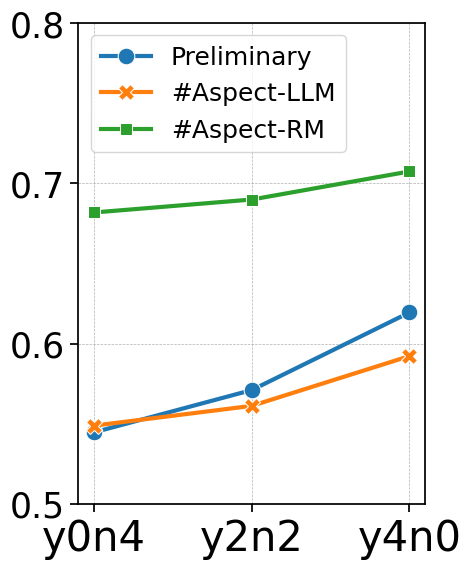

In [343]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # 1. 導入 numpy

# Load the dataset
try:
    # 確保您已經上傳 'summary_all_rename.csv' 檔案
    df = pd.read_csv('summary_all_rename.csv')
    print("數據加載成功！")
except FileNotFoundError:
    print("錯誤：'summary_all_rename.csv' 文件未找到。請確保文件在正確的路徑下或已上傳。")
    exit()

# --- 數據準備 (與您提供的代碼相同) ---
df['#AbsAspDiff'] = pd.to_numeric(df['#AbsAspDiff'], errors='coerce')
df['#AvgStep'] = pd.to_numeric(df['#AvgStep'], errors='coerce')
df['Total Tokens'] = pd.to_numeric(df['Total Tokens'], errors='coerce')

def parse_setting(setting):
    if pd.isna(setting):
        return None
    setting = str(setting).lower().strip()
    if 'y' in setting and 'n' in setting:
        parts = setting.split('n')
        y_count = int(parts[0].replace('y', '')) if parts[0].replace('y', '').isdigit() else 0
        n_count = int(parts[1]) if parts[1].isdigit() else 0
        return f"y{y_count}n{n_count}"
    elif 'y' in setting:
        y_count = int(setting.replace('y', '')) if setting.replace('y', '').isdigit() else 0
        return f"y{y_count}n0"
    elif 'n' in setting:
        n_count = int(setting.replace('n', '')) if setting.replace('n', '').isdigit() else 0
        return f"y0n{n_count}"
    return setting

df['Parsed Setting'] = df['Setting'].apply(parse_setting)
df.dropna(subset=['Parsed Setting'], inplace=True)

df_long_melted = df.melt(
    id_vars=['Parsed Setting', 'Model', 'PromptMethod', 'AspectType'],
    value_vars=['BERTScore'],
    var_name='Metric',
    value_name='Score'
)

df_long_melted['AspectTypeDisplay'] = df_long_melted['AspectType'].replace({
    'preliminary': 'Preliminary',
    'regression_model': '#Aspect-RM',
    'LLMs': '#Aspect-LLM'
})

prompt_name_mapping = {
    'direct_prompt': 'Direct',
    'cot_prompt': 'CoT',
    'cot_sc_prompt': 'CoT-SC',
    'self-refine': 'Self-Refine',
    'agentic_workflow': 'Agentic Workflow',
}
df_long_melted['Prompt'] = df_long_melted['PromptMethod'].map(prompt_name_mapping)
df_long_melted.dropna(subset=['Prompt'], inplace=True)

desired_prompt_order = ['Direct', 'CoT', 'CoT-SC', 'Self-Refine', 'Agentic Workflow']
df_long_melted['Prompt'] = pd.Categorical(
    df_long_melted['Prompt'],
    categories=[p for p in desired_prompt_order if p in df_long_melted['Prompt'].unique()],
    ordered=True
)
desired_aspect_order = ['Preliminary', '#Aspect-LLM', '#Aspect-RM']
df_long_melted['AspectTypeDisplay'] = pd.Categorical(
    df_long_melted['AspectTypeDisplay'],
    categories=[a for a in desired_aspect_order if a in df_long_melted['AspectTypeDisplay'].unique()],
    ordered=True
)

# 1. 篩選數據
target_settings = ['y0n4', 'y2n2', 'y4n0']
target_aspect_types = ['Preliminary', '#Aspect-LLM', '#Aspect-RM']

df_plot_data = df_long_melted[
    df_long_melted['Parsed Setting'].isin(target_settings) &
    df_long_melted['AspectTypeDisplay'].isin(target_aspect_types)
].copy()

df_plot_data['Parsed Setting'] = pd.Categorical(
    df_plot_data['Parsed Setting'],
    categories=target_settings,
    ordered=True
)

# 2. 數據聚合 (與之前相同)
df_aggregated = df_plot_data.groupby(['AspectTypeDisplay', 'Parsed Setting'], observed=False)['Score'].mean().reset_index()

# 3. 創建一個圖表畫布
plt.figure(figsize=(5, 6))

# 4. 在單一圖表上繪製所有折線
sns.lineplot(
    data=df_aggregated,
    x='Parsed Setting',
    y='Score',
    hue='AspectTypeDisplay',
    style='AspectTypeDisplay',
    markers=True,
    dashes=False,
    marker='o',
    linewidth=3,
    markersize=12
)

# 5. 設定圖表的標題和軸標籤
plt.xlabel('', fontsize=18)
plt.xticks(fontsize=30)

# --- 程式碼修改從這裡開始 ---
# 2. 【核心修改】設定Y軸刻度
# 使用 np.arange(start, stop, step) 來生成刻度。
# 因為 stop 是不包含的，所以我們使用 0.81 來確保 0.8 會被包含進去。
plt.yticks(np.arange(0.5, 0.81, 0.1), fontsize=25)
# --- 程式碼修改在這裡結束 ---
plt.ylabel('', fontsize=27, labelpad=15)
plt.ylim(0.5, 0.8)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 6. 調整圖例
plt.legend(title='', fontsize=18, title_fontsize='24', loc='upper left')

# 7. 自動調整版面並保存圖表
plt.tight_layout()
plt.savefig('bert_score_lines_combined_yticks.png', dpi=300)
# plt.show() # 如果在腳本中運行，可以取消註釋此行以顯示圖表

print("\n已生成並保存帶有自定義Y軸刻度的圖表 'bert_score_lines_combined_yticks.png'。")

In [ ]:
import pandas as pd

# Load the dataset
try:
    df = pd.read_csv('summary_all2.csv')
    print("數據加載成功！")
except FileNotFoundError:
    print("錯誤：'summary_all2.csv' 文件未找到。請確保文件在正確的路徑下。")
    exit()

# 數據清洗：確保數值列是數值類型
df['Gen_Count'] = pd.to_numeric(df['Gen_Count'], errors='coerce')

# 從 'Setting' 列解析出 'Provided Aspect Number' (初始提供的方面總數)
def parse_provided_aspect_count(setting_str):
    if pd.isna(setting_str):
        return None
    setting_str = str(setting_str).lower().strip()
    
    # 處理 yXnZ 格式
    if 'y' in setting_str and 'n' in setting_str:
        parts = setting_str.split('n')
        y_count_str = parts[0].replace('y', '')
        n_count_str = parts[1]
        try:
            y_count = int(y_count_str) if y_count_str else 0
            n_count = int(n_count_str) if n_count_str else 0
            return y_count + n_count
        except ValueError:
            return None # 如果轉換失敗
    # 處理 yX 格式 (全部正確)
    elif 'y' in setting_str:
        y_count_str = setting_str.replace('y', '')
        try:
            return int(y_count_str) if y_count_str else 0
        except ValueError:
            return None
    # 處理 nX 格式 (全部錯誤)
    elif 'n' in setting_str:
        n_count_str = setting_str.replace('n', '')
        try:
            return int(n_count_str) if n_count_str else 0
        except ValueError:
            return None
    return None # 如果格式不符合預期

df['ProvidedAspectCount'] = df['Setting'].apply(parse_provided_aspect_count)

# 移除任何因為解析失敗而產生的 NaN 行
df.dropna(subset=['ProvidedAspectCount', 'Gen_Count'], inplace=True)

# 為了更好地分析，將 AspectType 的名稱進行簡化或標準化
df['AspectTypeDisplay'] = df['AspectType'].replace({
    'original': 'Original Input',
    'pred': 'Predicted Number Guided',
    'csv': 'CSV Aspect (Baseline)', # 假設 'csv' 是某種基準或特定處理方式
    'regression_model': 'Regression Model Guided', # 確保與 'pred' 區分
    'LLMs': 'LLM Direct Predicted' # 確保與 'pred' 區分
})

# 將 'PromptMethod' 轉換為更友好的名稱，以便於分組和顯示
df['PromptMethodDisplay'] = df['PromptMethod'].replace({
    'direct_prompt': 'Direct',
    'cot_prompt': 'CoT',
    'cot_sc_prompt': 'CoT-SC',
    'self-refine': 'Self-Refine',
    'agentic_workflow': 'Agentic Workflow',
    'direct_prompt_with_csv_aspect': 'Direct (CSV)',
    'cot_prompt_with_csv_aspect': 'CoT (CSV)',
    'cot_sc_prompt_with_csv_aspect': 'CoT-SC (CSV)',
    'direct_prompt_with_predicted_aspect': 'Direct (Pred)',
    'cot_prompt_with_predicted_aspect': 'CoT (Pred)',
    'cot_sc_prompt_with_predicted_aspect': 'CoT-SC (Pred)',
})


# 按 'Model', 'AspectTypeDisplay', 'ProvidedAspectCount' 分組，計算 'Gen_Count' 的平均值
# 這裡我們只關注 AspectTypeDisplay 和 ProvidedAspectCount，因為 PromptMethodDisplay 會在表格中作為行或列
analysis_table = df.groupby(['Model', 'AspectTypeDisplay', 'ProvidedAspectCount'])['Gen_Count'].mean().unstack(level='AspectTypeDisplay')

# 為了更好的可讀性，可以對表格進行一些格式化
# 將 ProvidedAspectCount 設置為索引，如果需要
# analysis_table = analysis_table.reset_index().pivot(index='ProvidedAspectCount', columns='Model')

# 重新組織表格，讓 'ProvidedAspectCount', 'Model', 'PromptMethodDisplay' 成為索引，'AspectTypeDisplay' 成為列
# 這樣可以清晰地看到在不同初始方面數量下，不同模型、不同提示方法和 AspectType 的生成方面數量
analysis_table_pivot = df.groupby(['ProvidedAspectCount', 'Model', 'PromptMethodDisplay', 'AspectTypeDisplay'])['Gen_Count'].mean().unstack(level='AspectTypeDisplay')

# 打印結果
print("\n--- 不同模型、提示方法、AspectType 下，Provided Aspect Count 與 Generated Aspect Count 的關係 ---")
print(analysis_table_pivot.round(2))

# 可以選擇將結果保存到 CSV 文件
output_filename = "generated_aspect_count_analysis_by_prompt.csv"
analysis_table_pivot.to_csv(output_filename)
print(f"\n分析結果已保存到 '{output_filename}'")

數據加載成功！

--- 不同模型、提示方法、AspectType 下，Provided Aspect Count 與 Generated Aspect Count 的關係 ---
AspectTypeDisplay                                       CSV Aspect (Baseline)  \
ProvidedAspectCount Model          PromptMethodDisplay                          
2                   gemma-3-12b-it Agentic Workflow                      6.33   
                                   CoT                                   5.29   
                                   CoT-SC                                5.83   
                                   Direct                                6.61   
                    gemma-3-27b-it Agentic Workflow                      6.01   
...                                                                       ...   
12                  gpt-4o         Direct                                5.96   
                    gpt-4o-mini    Agentic Workflow                      6.33   
                                   CoT                                   5.93   
                  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    df_analysis = pd.read_csv('generated_aspect_count_analysis_by_prompt.csv')
    print("數據加載成功！")
except FileNotFoundError:
    print("錯誤：'generated_aspect_count_analysis_by_prompt.csv' 文件未找到。請確保文件在正確的路徑下。")
    exit()

# 數據清洗：確保數值列是數值類型
# ProvidedAspectCount 應該已經是數值，但 AspectTypeDisplay 的列需要轉換
# 先提取出代表 GeneratedAspectCount 的列名
generated_aspect_cols = [
    'Original Input',
    'Predicted Number Guided',
    'CSV Aspect (Baseline)',
    'Regression Model Guided',
    'LLM Direct Predicted'
]

# Identify which of the desired generated aspect columns are actually present in the loaded DataFrame
# This makes the melt operation robust to cases where some AspectTypeDisplay categories might not have data
actual_generated_aspect_cols = [col for col in generated_aspect_cols if col in df_analysis.columns]

# Check if any columns are missing from the expected list (optional, for debugging)
missing_cols = [col for col in generated_aspect_cols if col not in df_analysis.columns]
if missing_cols:
    print(f"Warning: The following expected 'AspectTypeDisplay' columns are missing from the loaded CSV: {missing_cols}. They will be excluded from the melt operation.")


# 將這些列轉換為數值類型，非數值設為 NaN
for col in actual_generated_aspect_cols:
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

# 為了繪圖，我們需要將數據從寬格式 (wide format) 轉換為長格式 (long format)
# 這樣 'AspectTypeDisplay' 就可以作為一個 hue 或 col/row 的變量
df_long = df_analysis.melt(
    id_vars=['ProvidedAspectCount', 'Model', 'PromptMethodDisplay'],
    value_vars=actual_generated_aspect_cols, # Use the filtered list of actual columns
    var_name='AspectTypeDisplay',
    value_name='GeneratedAspectCount'
)

# 移除 GeneratedAspectCount 為 NaN 的行
df_long.dropna(subset=['GeneratedAspectCount'], inplace=True)

# 定義 AspectTypeDisplay 的顯示順序 (可選，但有助於圖例和圖表的組織)
# Ensure categories only include those that are actually present in df_long after melting
desired_aspect_type_order = [
    'Original Input',
    'CSV Aspect (Baseline)',
    'LLM Direct Predicted',
    'Predicted Number Guided',
    'Regression Model Guided'
]
# Filter categories to only include those that exist in the melted DataFrame
existing_aspect_type_categories = [cat for cat in desired_aspect_type_order if cat in df_long['AspectTypeDisplay'].unique()]

df_long['AspectTypeDisplay'] = pd.Categorical(
    df_long['AspectTypeDisplay'],
    categories=existing_aspect_type_categories,
    ordered=True
)

# 定義 PromptMethodDisplay 的顯示名稱和順序
# 這裡確保 'Self-Refine' 和 'Agentic Workflow' 是獨立的類別
prompt_name_mapping = {
    'direct_prompt': 'Direct',
    'cot_prompt': 'CoT',
    'cot_sc_prompt': 'CoT-SC',
    'self-refine': 'Self-Refine',
    'agentic_workflow': 'Self-Refine', # 保持 Agentic Workflow 獨立
    'direct_prompt_with_csv_aspect': 'Direct (CSV)',
    'cot_prompt_with_csv_aspect': 'CoT (CSV)',
    'cot_sc_prompt_with_csv_aspect': 'CoT-SC (CSV)',
    'direct_prompt_with_predicted_aspect': 'Direct (Pred)',
    'cot_prompt_with_predicted_aspect': 'CoT (Pred)',
    'cot_sc_prompt_with_predicted_aspect': 'CoT-SC (Pred)',
}

# 替換 'PromptMethodDisplay' 列中的值為顯示名稱
df_long['Prompt'] = df_long['PromptMethodDisplay'].replace(prompt_name_mapping)

# 定義圖例的最終順序
desired_legend_order = [
    'Direct',
    'CoT',
    'CoT-SC',
    'Self-Refine',
    'Agentic Workflow', # 確保 Agentic Workflow 在圖例中
    'Direct (CSV)',
    'CoT (CSV)',
    'CoT-SC (CSV)',
    'Direct (Pred)',
    'CoT (Pred)',
    'CoT-SC (Pred)',
]

# 過濾出實際存在於數據中的類別，並按 desired_legend_order 排序
existing_prompt_method_categories = [cat for cat in desired_legend_order if cat in df_long['Prompt'].unique()]
df_long['Prompt'] = pd.Categorical(
    df_long['Prompt'],
    categories=existing_prompt_method_categories,
    ordered=True
)

# --- 新增的過濾步驟：只繪製 'Original Input' ---
df_plot_filtered = df_long[df_long['AspectTypeDisplay'] == 'Original Input'].copy()
if df_plot_filtered.empty:
    print("Warning: 'Original Input' 數據在篩選後為空，無法生成圖表。請檢查數據或 AspectTypeDisplay 的名稱。")
    exit()


# --- 繪製散點圖 ---
g = sns.relplot(
    data=df_plot_filtered, # 使用過濾後的數據
    x='ProvidedAspectCount',
    y='GeneratedAspectCount',
    col='Model',
    hue='Prompt', # 現在 hue 是提示方法
    # style='PromptMethodDisplay',
    kind='scatter', # 散點圖
    col_wrap=2, # 每行顯示 2 個子圖
    height=5, aspect=1.2, # 子圖大小
    s=100, # 點的大小
    palette='viridis', # 調色板
    facet_kws={'sharex': True, 'sharey': True} # 共享 X 和 Y 軸範圍,
)

# 添加回歸線 (在每個子圖中添加)
for ax in g.axes.flat:
    sns.regplot(
        data=df_plot_filtered, # 使用過濾後的數據
        x='ProvidedAspectCount',
        y='GeneratedAspectCount',
        scatter=False, # 不重複繪製散點，只繪製回歸線
        ax=ax, # 在當前子圖上繪製
        color='gray', # 回歸線顏色
        line_kws={'linestyle': '--', 'alpha': 0.7} # 回歸線樣式
    )
    # 移除紅色虛線：將此行註釋掉或刪除
    # ax.plot([min(x0,y0), max(x1,y1)], [min(x0,y0), max(x1,y1)],
    #         color='red', linestyle=':', alpha=0.6, label='Ideal Match')


# 調整標題和軸標籤
g.set_axis_labels("Provided Aspect Count", "Generated Aspect Count", fontsize=23, labelpad=20)
g.set_titles("{col_name}", size=20)

leg = g._legend
leg.set_bbox_to_anchor([0.0015, 0.95])  # coordinates of lower left of bounding box
leg._loc = 2  # if required you can set the loc
leg.set_title("Prompt", prop={"size": 20})
for text in leg.texts:
    text.set_fontsize(16)

# g.move_legend("right", loc="center left", title='Prompt')
# 調整圖例位置和標題
# 將圖例標題改為 'Prompt'
# bbox_to_anchor 調整到圖外右側，loc='upper left' 確保從左上角開始
# borderaxespad=0. 減少圖例與軸之間的填充
# 如果圖例還是壓線，可以嘗試調整 rect=[0, 0, 0.85, 1] 或更小，為圖例留出更多空間
# g.add_legend(title="Prompt", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# plt.suptitle('Provided vs. Generated Aspect Count for Original Input Across Models', y=1.02, fontsize=16) # 總標題

# 調整整個圖表的佈局，為圖例留出更多空間
# rect=[left, bottom, right, top]
# 這裡將 right 設置為 0.85，為右側圖例留出 15% 的空間
plt.tight_layout(rect=[0.15, 0, 1, 1])
plt.savefig('provided_vs_generated_aspect_count_original_input_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n分析腳本已執行。圖表 'provided_vs_generated_aspect_count_original_input_plot.png' 已生成並保存。")


數據加載成功！


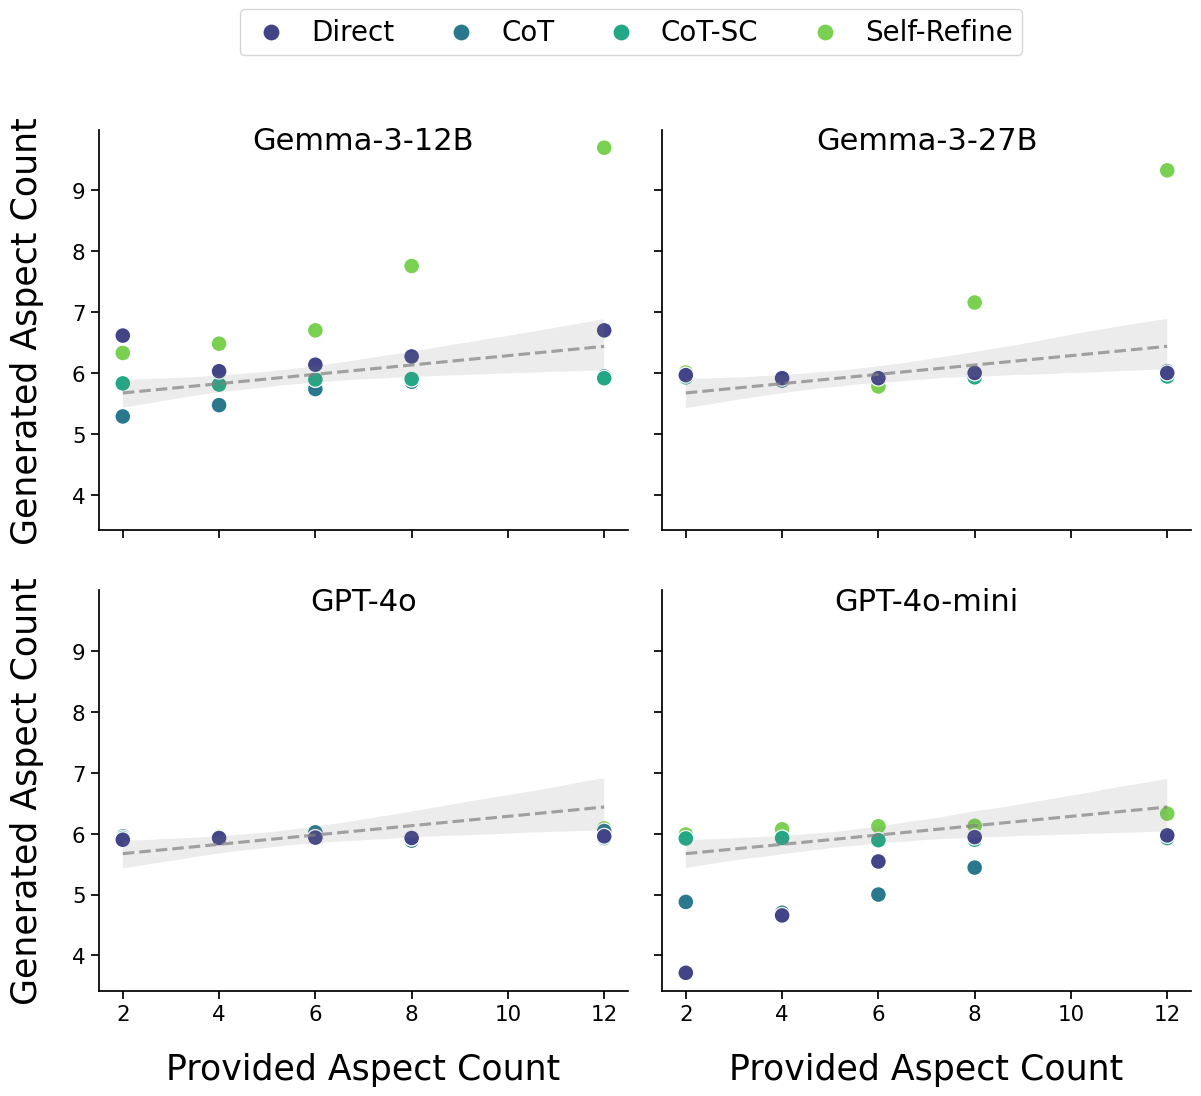


分析腳本已執行。圖表 'provided_vs_generated_aspect_count_original_input_plot.png' 已生成並保存。


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    df_analysis = pd.read_csv('generated_aspect_count_analysis_by_prompt.csv')
    print("數據加載成功！")
except FileNotFoundError:
    print("錯誤：'generated_aspect_count_analysis_by_prompt.csv' 文件未找到。請確保文件在正確的路徑下。")
    exit()

# 數據清洗：確保數值列是數值類型
# ProvidedAspectCount 應該已經是數值，但 AspectTypeDisplay 的列需要轉換
# 先提取出代表 GeneratedAspectCount 的列名
generated_aspect_cols = [
    'Original Input',
    'Predicted Number Guided',
    'CSV Aspect (Baseline)',
    'Regression Model Guided',
    'LLM Direct Predicted'
]

# Identify which of the desired generated aspect columns are actually present in the loaded DataFrame
# This makes the melt operation robust to cases where some AspectTypeDisplay categories might not have data
actual_generated_aspect_cols = [col for col in generated_aspect_cols if col in df_analysis.columns]

# Check if any columns are missing from the expected list (optional, for debugging)
missing_cols = [col for col in generated_aspect_cols if col not in df_analysis.columns]
if missing_cols:
    print(f"Warning: The following expected 'AspectTypeDisplay' columns are missing from the loaded CSV: {missing_cols}. They will be excluded from the melt operation.")


# 將這些列轉換為數值類型，非數值設為 NaN
for col in actual_generated_aspect_cols:
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

# 為了繪圖，我們需要將數據從寬格式 (wide format) 轉換為長格式 (long format)
# 這樣 'AspectTypeDisplay' 就可以作為一個 hue 或 col/row 的變量
df_long = df_analysis.melt(
    id_vars=['ProvidedAspectCount', 'Model', 'PromptMethodDisplay'],
    value_vars=actual_generated_aspect_cols, # Use the filtered list of actual columns
    var_name='AspectTypeDisplay',
    value_name='GeneratedAspectCount'
)

# 移除 GeneratedAspectCount 為 NaN 的行
df_long.dropna(subset=['GeneratedAspectCount'], inplace=True)

# 定義 AspectTypeDisplay 的顯示順序 (可選，但有助於圖例和圖表的組織)
# Ensure categories only include those that are actually present in df_long after melting
desired_aspect_type_order = [
    'Original Input',
    'CSV Aspect (Baseline)',
    'LLM Direct Predicted',
    'Predicted Number Guided',
    'Regression Model Guided'
]
# Filter categories to only include those that exist in the melted DataFrame
existing_aspect_type_categories = [cat for cat in desired_aspect_type_order if cat in df_long['AspectTypeDisplay'].unique()]

df_long['AspectTypeDisplay'] = pd.Categorical(
    df_long['AspectTypeDisplay'],
    categories=existing_aspect_type_categories,
    ordered=True
)

# 定義 PromptMethodDisplay 的顯示名稱和順序
# 這裡確保 'Self-Refine' 和 'Agentic Workflow' 是獨立的類別
prompt_name_mapping = {
    'direct_prompt': 'Direct',
    'cot_prompt': 'CoT',
    'cot_sc_prompt': 'CoT-SC',
    'self-refine': 'Self-Refine',
    'agentic_workflow': 'Self-Refine', # 保持 Agentic Workflow 獨立
    'direct_prompt_with_csv_aspect': 'Direct (CSV)',
    'cot_prompt_with_csv_aspect': 'CoT (CSV)',
    'cot_sc_prompt_with_csv_aspect': 'CoT-SC (CSV)',
    'direct_prompt_with_predicted_aspect': 'Direct (Pred)',
    'cot_prompt_with_predicted_aspect': 'CoT (Pred)',
    'cot_sc_prompt_with_predicted_aspect': 'CoT-SC (Pred)',
}

# 替換 'PromptMethodDisplay' 列中的值為顯示名稱
df_long['Prompt'] = df_long['PromptMethodDisplay'].replace(prompt_name_mapping)

# 定義圖例的最終順序
desired_legend_order = [
    'Direct',
    'CoT',
    'CoT-SC',
    'Self-Refine',
    'Agentic Workflow', # 確保 Agentic Workflow 在圖例中
    'Direct (CSV)',
    'CoT (CSV)',
    'CoT-SC (CSV)',
    'Direct (Pred)',
    'CoT (Pred)',
    'CoT-SC (Pred)',
]

# 過濾出實際存在於數據中的類別，並按 desired_legend_order 排序
existing_prompt_method_categories = [cat for cat in desired_legend_order if cat in df_long['Prompt'].unique()]
df_long['Prompt'] = pd.Categorical(
    df_long['Prompt'],
    categories=existing_prompt_method_categories,
    ordered=True
)

# --- 新增的過濾步驟：只繪製 'Original Input' ---
df_plot_filtered = df_long[df_long['AspectTypeDisplay'] == 'CSV Aspect (Baseline)'].copy()
# aspect_types_to_average = ['Original Input', 'CSV Aspect (Baseline)', 'Predicted Number Guided']
# df_filtered_for_avg = df_long[df_long['AspectTypeDisplay'].isin(aspect_types_to_average)].copy()
# df_averaged = df_filtered_for_avg.groupby(['ProvidedAspectCount', 'Model', 'Prompt'])['GeneratedAspectCount'].mean().reset_index()
# df_plot_filtered = df_averaged
if df_plot_filtered.empty:
    print("Warning: 'Original Input' 數據在篩選後為空，無法生成圖表。請檢查數據或 AspectTypeDisplay 的名稱。")
    exit()


# --- 繪製散點圖 ---
g = sns.relplot(
    data=df_plot_filtered, # 使用過濾後的數據
    x='ProvidedAspectCount',
    y='GeneratedAspectCount',
    col='Model',
    hue='Prompt', # 現在 hue 是提示方法
    # style='PromptMethodDisplay',
    kind='scatter', # 散點圖
    col_wrap=2, # 每行顯示 2 個子圖
    height=5, aspect=1.2, # 子圖大小
    s=130, # 點的大小
    palette='viridis', # 調色板
    facet_kws={'sharex': True, 'sharey': True}, # 共享 X 和 Y 軸範圍
    # legend=False, # 
)

# 添加回歸線 (在每個子圖中添加)
for ax in g.axes.flat:
    sns.regplot(
        data=df_plot_filtered, # 使用過濾後的數據
        x='ProvidedAspectCount',
        y='GeneratedAspectCount',
        scatter=False, # 不重複繪製散點，只繪製回歸線
        ax=ax, # 在當前子圖上繪製
        color='gray', # 回歸線顏色
        line_kws={'linestyle': '--', 'alpha': 0.7} # 回歸線樣式
    )
    # 移除紅色虛線：將此行註釋掉或刪除
    # ax.plot([min(x0,y0), max(x1,y1)], [min(x0,y0), max(x1,y1)],
    #         color='red', linestyle=':', alpha=0.6, label='Ideal Match')


# 調整標題和軸標籤
replace_dict = {
    "gemma-3-12b-it": "Gemma-3-12B",
    "gemma-3-27b-it": "Gemma-3-27B",
    "gpt-4o": "GPT-4o",
    "gpt-4o-mini": "GPT-4o-mini"
}
g.set_axis_labels("Provided Aspect Count", "Generated Aspect Count", fontsize=25, labelpad=20)
# g.set_titles("{col_name}", size=20)
for ax, title in zip(g.axes.flat, g.col_names):
    # 從字典中獲取新標題，如果找不到則使用原標題
    new_title = replace_dict.get(title, title)
    ax.set_title(new_title, size=22, y=0.93)

sns.move_legend(g, "upper center", bbox_to_anchor=(0.45, 1.08), ncol=4, title='', frameon=True, title_fontsize='20', fontsize='16')

leg = g._legend
# leg.set_bbox_to_anchor([0.06, 0.995])  # coordinates of lower left of bounding box
# leg._loc = 2  # if required you can set the loc
# legend font size
# leg.set_title("Prompt", prop={"size": 20})
for text in leg.texts:
    text.set_fontsize(20)
# g.move_legend("right", loc="center left", title='Prompt')
# 調整圖例位置和標題
# 將圖例標題改為 'Prompt'
# bbox_to_anchor 調整到圖外右側，loc='upper left' 確保從左上角開始
# borderaxespad=0. 減少圖例與軸之間的填充
# 如果圖例還是壓線，可以嘗試調整 rect=[0, 0, 0.85, 1] 或更小，為圖例留出更多空間
# g.add_legend(title="Prompt", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# plt.suptitle('Provided vs. Generated Aspect Count for Original Input Across Models', y=1.02, fontsize=16) # 總標題

# 調整整個圖表的佈局，為圖例留出更多空間
# rect=[left, bottom, right, top]
# 這裡將 right 設置為 0.85，為右側圖例留出 15% 的空間
# plt.tight_layout(rect=[0.15, 0, 1, 1])
plt.savefig('provided_vs_generated_aspect_count_csv.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n分析腳本已執行。圖表 'provided_vs_generated_aspect_count_original_input_plot.png' 已生成並保存。")


數據加載成功！


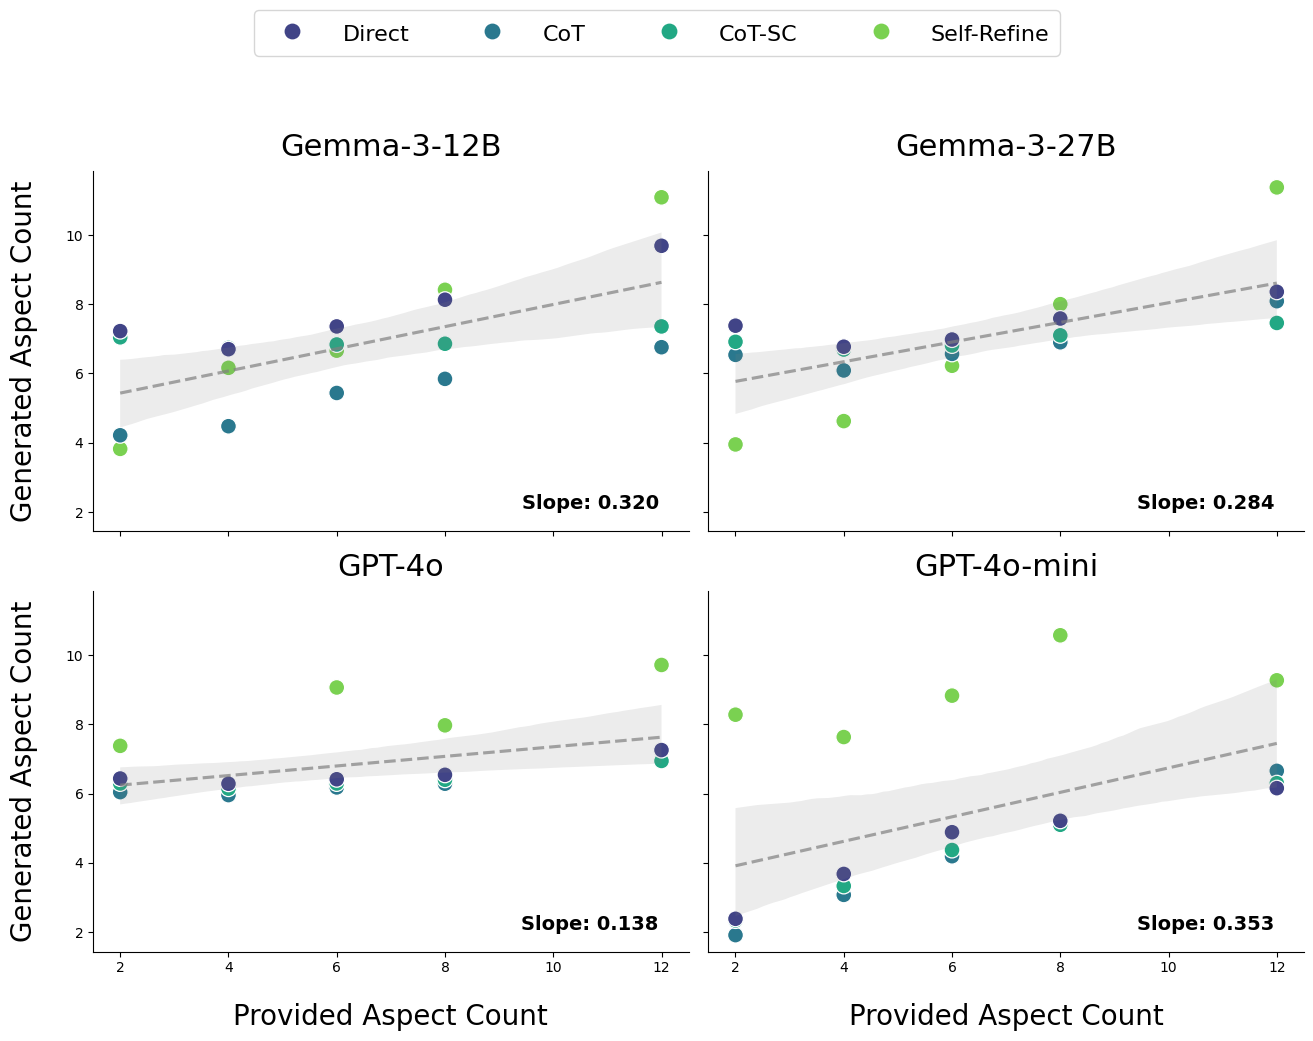


分析腳本已執行。包含迴歸線、信賴區間和斜率標註的圖表 'provided_vs_generated_final.png' 已生成並保存。


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

# --- 1. 數據加載與準備 ---

# 加載數據集
try:
    df_analysis = pd.read_csv('generated_aspect_count_analysis_by_prompt.csv')
    print("數據加載成功！")
except FileNotFoundError:
    print("錯誤：'generated_aspect_count_analysis_by_prompt.csv' 文件未找到。請確保文件在正確的路徑下。")
    exit()

# 提取代表 GeneratedAspectCount 的列名
generated_aspect_cols = [
    'Original Input', 'Predicted Number Guided', 'CSV Aspect (Baseline)',
    'Regression Model Guided', 'LLM Direct Predicted'
]
actual_generated_aspect_cols = [col for col in generated_aspect_cols if col in df_analysis.columns]

# 將數值列轉換為數值類型
for col in actual_generated_aspect_cols:
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

# 將數據從寬格式轉換為長格式
df_long = df_analysis.melt(
    id_vars=['ProvidedAspectCount', 'Model', 'PromptMethodDisplay'],
    value_vars=actual_generated_aspect_cols,
    var_name='AspectTypeDisplay',
    value_name='GeneratedAspectCount'
)
df_long.dropna(subset=['GeneratedAspectCount'], inplace=True)

# --- 2. 數據整理與分類 ---

# 定義 PromptMethodDisplay 的顯示名稱
prompt_name_mapping = {
    'direct_prompt': 'Direct', 'cot_prompt': 'CoT', 'cot_sc_prompt': 'CoT-SC',
    'self-refine': 'Self-Refine', 'agentic_workflow': 'Agentic Workflow',
    'direct_prompt_with_csv_aspect': 'Direct (CSV)', 'cot_prompt_with_csv_aspect': 'CoT (CSV)',
    'cot_sc_prompt_with_csv_aspect': 'CoT-SC (CSV)',
    'direct_prompt_with_predicted_aspect': 'Direct (Pred)',
    'cot_prompt_with_predicted_aspect': 'CoT (Pred)',
    'cot_sc_prompt_with_predicted_aspect': 'CoT-SC (Pred)',
}
df_long['Prompt'] = df_long['PromptMethodDisplay'].replace(prompt_name_mapping)

# 定義圖例的順序
desired_legend_order = [
    'Direct', 'CoT', 'CoT-SC', 'Self-Refine', 'Agentic Workflow',
    'Direct (CSV)', 'CoT (CSV)', 'CoT-SC (CSV)',
    'Direct (Pred)', 'CoT (Pred)', 'CoT-SC (Pred)',
]
existing_prompt_method_categories = [cat for cat in desired_legend_order if cat in df_long['Prompt'].unique()]
df_long['Prompt'] = pd.Categorical(
    df_long['Prompt'], categories=existing_prompt_method_categories, ordered=True
)

# --- 3. 數據篩選 ---

# 只繪製 'CSV Aspect (Baseline)'
df_plot_filtered = df_long[df_long['AspectTypeDisplay'] == 'Original Input'].copy()
if df_plot_filtered.empty:
    print("警告: 'CSV Aspect (Baseline)' 數據在篩選後為空，無法生成圖表。")
    exit()

# --- 4. 繪製散點圖 ---

g = sns.relplot(
    data=df_plot_filtered,
    x='ProvidedAspectCount',
    y='GeneratedAspectCount',
    col='Model',
    hue='Prompt',
    kind='scatter',
    col_wrap=2,
    height=5, aspect=1.2,
    s=130,
    palette='viridis',
    facet_kws={'sharex': True, 'sharey': True},
)

# --- 5. 繪製迴歸線、信賴區間並標註斜率 (核心修改部分) ---

# 遍歷每個子圖 (ax) 和對應的 Model 名稱
for ax, model_name in zip(g.axes.flat, g.col_names):
    # 獲取當前子圖的所有數據
    df_subset = df_plot_filtered[df_plot_filtered['Model'] == model_name]
    
    # 確保有足夠的數據點
    if len(df_subset) > 1:
        # **步驟一：使用 Seaborn 繪製迴歸線和信賴區間 (灰色區塊)**
        # 我們在這裡傳入 df_subset，確保只對當前子圖的數據進行迴歸
        sns.regplot(
            data=df_subset,
            x='ProvidedAspectCount',
            y='GeneratedAspectCount',
            scatter=False,  # 不重複繪製散點
            ax=ax,          # 在當前子圖上繪製
            color='gray',
            line_kws={'linestyle': '--', 'alpha': 0.7}
        )
        
        # **步驟二：使用 statsmodels 獨立計算斜率以便標註**
        X = df_subset['ProvidedAspectCount']
        y = df_subset['GeneratedAspectCount']
        X_with_const = sm.add_constant(X)
        model = sm.OLS(y, X_with_const).fit()
        slope = model.params['ProvidedAspectCount']
        
        # **步驟三：在圖的右下角標註斜率**
        ax.text(
            0.95, 0.05, # 相對位置 (x=95%, y=5%)
            f'Slope: {slope:.3f}', # 顯示斜率，格式化到小數點後三位
            transform=ax.transAxes, # 使用相對於座標軸的座標系統
            fontsize=14, 
            fontweight='bold',
            ha='right', # 水平對齊：右
            va='bottom' # 垂直對齊：底
        )

# --- 6. 調整圖表樣式 ---

# 調整子圖標題
replace_dict = {
    "gemma-3-12b-it": "Gemma-3-12B", "gemma-3-27b-it": "Gemma-3-27B",
    "gpt-4o": "GPT-4o", "gpt-4o-mini": "GPT-4o-mini"
}
for ax, title in zip(g.axes.flat, g.col_names):
    new_title = replace_dict.get(title, title)
    ax.set_title(new_title, size=22, y=1.02)

g.set_axis_labels("Provided Aspect Count", "Generated Aspect Count", fontsize=20, labelpad=20)

# 調整圖例位置和樣式
# sns.move_legend(g, "upper center", bbox_to_anchor=(0.45, 1.1), ncol=4, title='', frameon=True)
sns.move_legend(g, "upper center", bbox_to_anchor=(0.5, 1.05), ncol=4, title='', frameon=True, title_fontsize='20', fontsize='20')
leg = g._legend
for text in leg.texts:
    text.set_fontsize(16)

# 調整整體佈局
plt.tight_layout(rect=[0, 0, 1, 0.93])

# --- 7. 保存並顯示圖表 ---

plt.savefig('provided_vs_generated_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n分析腳本已執行。包含迴歸線、信賴區間和斜率標註的圖表 'provided_vs_generated_final.png' 已生成並保存。")

## Main Table

In [ ]:
import pandas as pd

# 讀取原始資料
df = pd.read_csv("summary_all.csv")

# 要處理的指標
metrics = ['BERTScore', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']


# 儲存所有結果的清單
results = []

# 針對每個指標進行 groupby 並轉換為 pivot 格式
for metric in metrics:
    grouped_df = df.groupby(['PromptMethod', 'AspectType', 'Model'])[metric].mean().reset_index()
    pivot_df = grouped_df.pivot_table(index=['PromptMethod', 'AspectType'], columns='Model', values=metric)

    # 按照指定欄位順序排列
    desired_order = ['gemma-3-12b-it', 'gemma-3-27b-it', 'gpt-4o-mini', 'gpt-4o']
    pivot_df = pivot_df[desired_order]

    # 加上 multiindex 的 metric label
    pivot_df.columns = pd.MultiIndex.from_product([[metric], pivot_df.columns])
    results.append(pivot_df)

# 將所有指標合併成一個表格
final_df = pd.concat(results, axis=1)

# 儲存成 CSV 檔案
final_df.to_csv("bert_rouge_summary.csv", index=True)


In [29]:
import pandas as pd
import numpy as np

# 讀取原始資料
df = pd.read_csv("summary_all3.csv")

# 要處理的指標
metrics = ['BERTScore', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', '#AbsAspDiff']

# 儲存每個模型的資料
model_dfs = []

# 模型順序
# ordered_models = ['gemma-3-12b-it', 'gemma-3-27b-it', 'gpt-4o-mini', 'gpt-4o']
ordered_models = ["gemini-2.5-flash-lite", "o3-mini-2025-01-31"]


name_map = {
    'original': 'Preliminary',
    'csv': '#Aspect-RM',
    'pred': '#Aspect-LLM'
}

df['AspectType'] = df['AspectType'].replace(name_map)

name_map2 = {
    'direct_prompt': 'Direct',
    'cot_prompt': 'CoT',
    'cot_sc_prompt': 'CoT-SC',
    'self-refine': 'Self-Refine',
    'agentic_workflow': 'Self-Refine',
}
df['PromptMethod'] = df['PromptMethod'].replace(name_map2)


# PromptMethod 順序
prompt_order = ['Direct', 'CoT', 'CoT-SC', 'Self-Refine', 'Agentic Workflow']

# 依模型處理每個子表格
for model in ordered_models:
    model_df = df[df['Model'] == model].groupby(['PromptMethod', 'AspectType'])[metrics].mean().reset_index()
    model_df['Model'] = model  # 加入 model 欄
    model_dfs.append(model_df)

# 合併所有模型
merged_df = pd.concat(model_dfs, axis=0)

# 設定 index：模型、PromptMethod、AspectType
merged_df.set_index(['Model', 'PromptMethod', 'AspectType'], inplace=True)

# 攤平欄位順序：以模型為 major index，欄位為 metrics
final_df = merged_df.unstack(level=0)

# 重新排列欄位順序（每個模型下的 BERTScore, ROUGE-1, ROUGE-2, ROUGE-L）
ordered_metrics = ['BERTScore', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', '#AbsAspDiff']
final_df = final_df[[ (metric, model) for model in ordered_models for metric in ordered_metrics ]]

# 重設 index，方便排序
final_df = final_df.reset_index()

# 確保 PromptMethod 有正確順序
final_df['PromptMethod'] = pd.Categorical(final_df['PromptMethod'], categories=prompt_order, ordered=True)
# final_df = final_df.sort_values(['PromptMethod', 'AspectType']).set_index(['PromptMethod', 'AspectType'])
final_df = final_df.sort_values(['AspectType', 'PromptMethod']).set_index(['AspectType', 'PromptMethod'])
# 替換 AspectType 的名稱

# 無條件捨去到小數點後第四位
def truncate(x):
    if isinstance(x, float):
        return np.floor(x * 10000) / 10000
    return x

final_df = final_df.applymap(truncate)

# 儲存成 CSV
final_df.to_csv("bert_rouge_summary_by_model_2.csv")


/tmp/ipykernel_3096363/3348440376.py:73: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  final_df = final_df.applymap(truncate)


In [19]:
import pandas as pd

# Step 1：讀取原始 CSV（不指定標題，保留原始格式）
file_path = "bert_rouge_summary.csv"  # ← 修改為你自己的檔案路徑
df = pd.read_csv(file_path, header=None)

# Step 2：第一列作為欄位名稱，跳過第二列說明列，從第三列開始取資料
df.columns = df.iloc[0]  # 第0列作為欄位名（模型名稱）
df_cleaned = df[2:].reset_index(drop=True)  # 去除前兩列

# Step 3：重新命名前兩欄為 PromptMethod 和 AspectType
df_cleaned.columns.values[0:2] = ["PromptMethod", "AspectType"]

# Step 4：定義各個指標對應的欄位（順序與原始表格一致）
metric_groups = {
    "BERTScore": df_cleaned.columns[2:6],   # 4欄：gemma3-12b, 27b, gpt-4o-mini, gpt-4o
    "ROUGE-1": df_cleaned.columns[6:10],
    "ROUGE-2": df_cleaned.columns[10:14],
    "ROUGE-L": df_cleaned.columns[14:18],
}

# Step 5：建立新的 DataFrame 存放平均值
output_df = df_cleaned[["PromptMethod", "AspectType"]].copy()

# Step 6：對每個 metric 取平均
for metric, cols in metric_groups.items():
    output_df[metric] = df_cleaned[cols].astype(float).mean(axis=1)

# Step 7：輸出成新的 CSV
output_path = "average_by_metric_group.csv"  # ← 你可以改成任何你想儲存的檔名
output_df.to_csv(output_path, index=False)


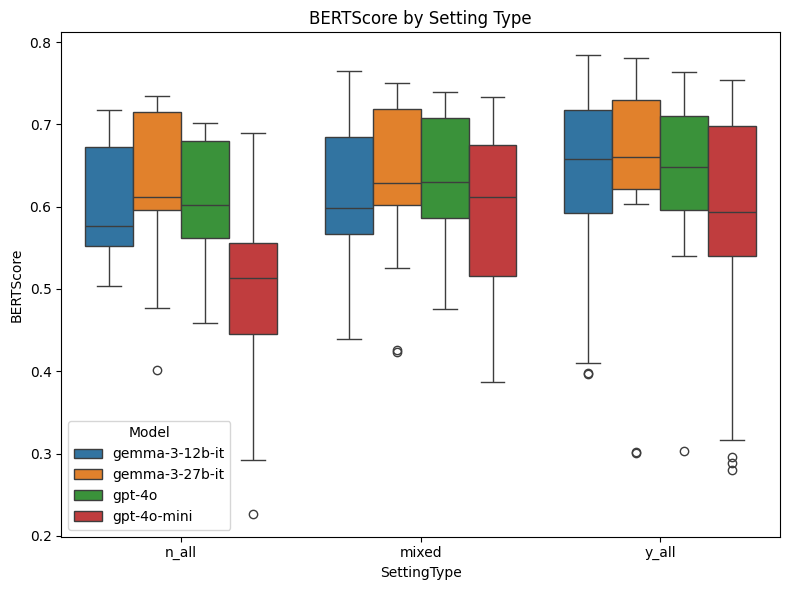

In [10]:
def classify_setting(setting):
    y = int(setting[1])
    n = int(setting[3])
    if y > 0 and n == 0:
        return "y_all"
    elif n > 0 and y == 0:
        return "n_all"
    else:
        return "mixed"
df = pd.read_csv("./summary_all.csv")
df["SettingType"] = df["Setting"].apply(classify_setting)
df["SettingType"] = pd.Categorical(df["SettingType"], categories=["n_all", "mixed", "y_all"], ordered=True)


plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="SettingType", y="BERTScore", hue="Model")
plt.title("BERTScore by Setting Type")
plt.tight_layout()
plt.show()


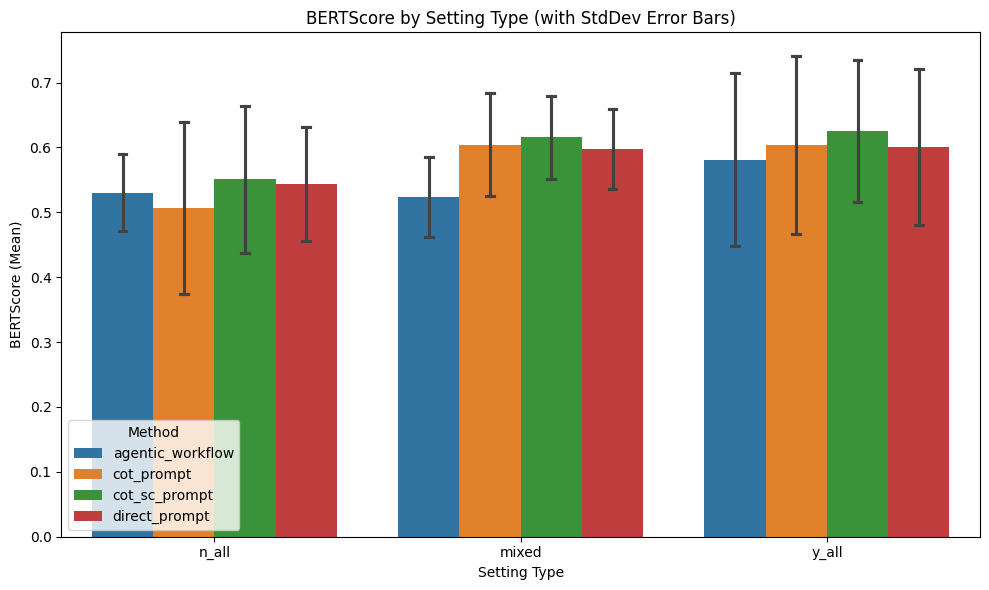

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


df["SettingType"] = df["Setting"].apply(classify_setting)

plt.figure(figsize=(10, 6))

# Seaborn v0.12.0+可以直接在繪圖時計算平均值與標準差
# 透過 errorbar="sd" 參數，它會自動計算標準差 (Standard Deviation) 並繪製成誤差線
ax = sns.barplot(
    data=df,
    x="SettingType",
    y="BERTScore",  # 直接使用原始分數欄位
    hue="Method",
    errorbar="sd",  # "sd" 代表標準差 (Standard Deviation)
    capsize=0.1     # 這個 capsize 會自動應用到誤差線上
)

plt.title("BERTScore by Setting Type (with StdDev Error Bars)")
plt.ylabel("BERTScore (Mean)")
plt.xlabel("Setting Type")
plt.tight_layout()
plt.show()

圖表已依照新的順序與名稱儲存至 setting_aspect_bertscore_ordered.png


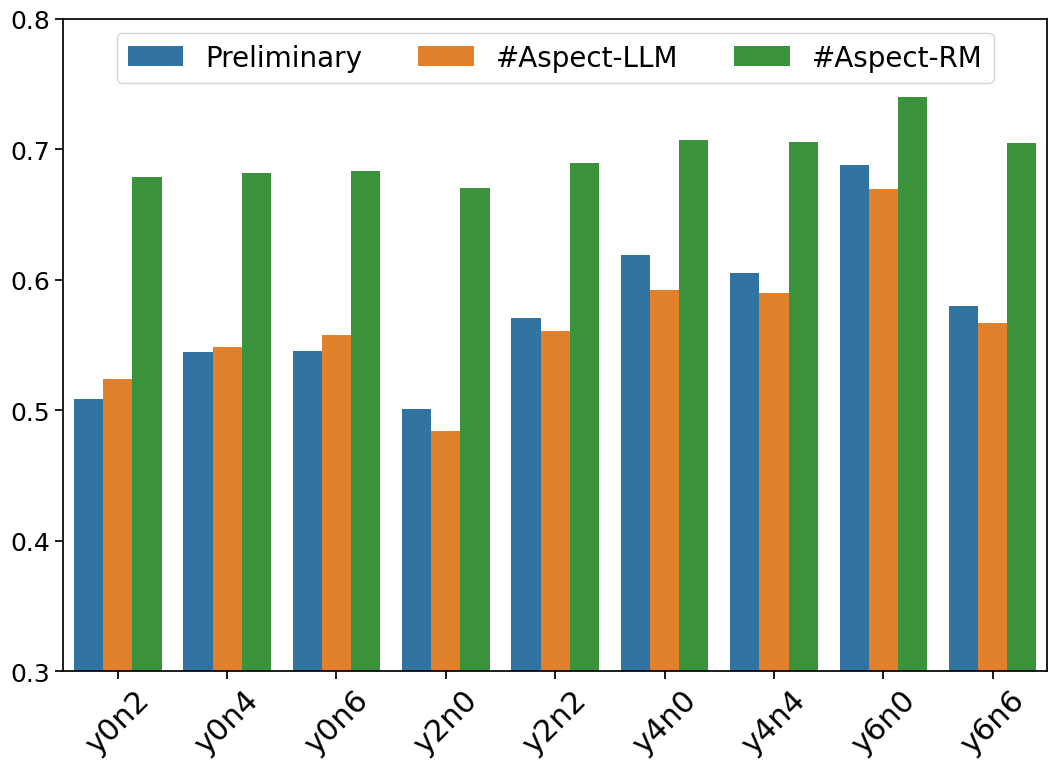

In [398]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取您的 CSV 檔案
df = pd.read_csv('summary_all_rename.csv')

# --- 1. 更名與排序 ---
# 定義新的名稱對應關係
name_map = {
    'preliminary': 'Preliminary',
    'regression_model': '#Aspect-RM',
    'LLMs': '#Aspect-LLM'
}
# 定義您想要的順序
aspect_order = ['Preliminary',  '#Aspect-LLM', '#Aspect-RM']

# 應用新的名稱
df['AspectType'] = df['AspectType'].replace(name_map)

# 將 'AspectType' 轉換為帶有指定順序的類別型資料
df['AspectType'] = pd.Categorical(df['AspectType'], categories=aspect_order, ordered=True)

# --- 2. 彙整數據 ---
# 依據 'Setting' 和 'AspectType' 分組，並計算 'BERTScore' 的平均值
agg_df = df.groupby(['Setting', 'AspectType'], observed=False)['BERTScore'].mean().reset_index()

# --- 3. 繪製圖表 ---
plt.figure(figsize=(11, 8))
# 使用 hue_order 參數來確保 seaborn 依照您要的順序繪圖
sns.barplot(data=agg_df, x='Setting', y='BERTScore', hue='AspectType', hue_order=aspect_order)

# 設定圖表標題和標籤
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.ylim(0.3, 0.8)
plt.xticks(rotation=45, fontsize=22)
plt.yticks(fontsize=18)
plt.legend(title='', fontsize=20, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1), frameon=True)
plt.tight_layout()

# 儲存更新後的圖檔
plt.savefig('setting_aspect_bertscore_ordered.png')

print("圖表已依照新的順序與名稱儲存至 setting_aspect_bertscore_ordered.png")